<a href="https://colab.research.google.com/github/MuhammadAhmadZia/Ecommerce-Product-Rating-Prediction-using-Bin-Wise-Quantized-CatBoost/blob/main/Copy_of_platform_seperation_code_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# split_by_platform.py
# Usage:
#  - In Google Colab: set DRIVE_MODE = 'colab' (will mount Drive and use MyDrive/MYResearchWork)
#  - Locally: set DRIVE_MODE = 'local' and change LOCAL_BASE_PATH to your Google Drive folder path

import os
import pandas as pd

# ---------- CONFIG ----------
DRIVE_MODE = 'colab'   # 'colab' or 'local'
INPUT_FILENAME = 'dataset.csv'  # change to 'dataset.cvs' if that's the real name
LOCAL_BASE_PATH = r'/path/to/GoogleDrive/MYResearchWork'  # set when DRIVE_MODE='local'
COLAB_BASE_PATH = '/content/drive/MyDrive/MYResearchWork'  # standard for Colab
# ----------------------------

# prepare base path
if DRIVE_MODE == 'colab':
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
    except Exception as e:
        print("Could not mount Drive automatically. If running outside Colab, switch DRIVE_MODE to 'local'.")
        raise
    base_path = COLAB_BASE_PATH
else:
    base_path = LOCAL_BASE_PATH

input_path = os.path.join(base_path, INPUT_FILENAME)
if not os.path.exists(input_path):
    raise FileNotFoundError(f"Input file not found: {input_path}\nPlease check INPUT_FILENAME and base path.")

# load dataset
df = pd.read_csv(input_path)
print(f"Loaded dataset with shape: {df.shape}")

# verify platform column exists
if 'platform' not in df.columns:
    raise KeyError("Column 'platform' not found in the dataset. Please check the column names.")

# normalize platform values (trim + lowercase)
df['platform'] = df['platform'].astype(str).str.strip().str.lower()

# split
amazon_df = df[df['platform'] == 'amazon'].copy()
flipkart_df = df[df['platform'] == 'flipkart'].copy()

print(f"Rows -> Amazon: {len(amazon_df)}, Flipkart: {len(flipkart_df)}, Other: {len(df) - len(amazon_df) - len(flipkart_df)}")

# drop platform column (as requested)
amazon_df = amazon_df.drop(columns=['platform'])
flipkart_df = flipkart_df.drop(columns=['platform'])

# output filenames
amazon_out = os.path.join(base_path, 'dataset_amazon.csv')
flipkart_out = os.path.join(base_path, 'dataset_flipkart.csv')

# save
amazon_df.to_csv(amazon_out, index=False)
flipkart_df.to_csv(flipkart_out, index=False)

print("Saved files:")
print(" -", amazon_out)
print(" -", flipkart_out)

# optional: if some rows didn't match either label, save them too
others = df[~df['platform'].isin(['amazon','flipkart'])]
if len(others) > 0:
    others_out = os.path.join(base_path, 'dataset_other_platforms.csv')
    # drop platform before saving (or keep if you prefer)
    others.drop(columns=['platform']).to_csv(others_out, index=False)
    print(f"Also found {len(others)} rows with other platform values. Saved to: {others_out}")


Mounted at /content/drive
Loaded dataset with shape: (15730, 16)
Rows -> Amazon: 341, Flipkart: 15389, Other: 0
Saved files:
 - /content/drive/MyDrive/MYResearchWork/dataset_amazon.csv
 - /content/drive/MyDrive/MYResearchWork/dataset_flipkart.csv


In [ ]:
import pandas as pd
from google.colab import drive
from sklearn.preprocessing import LabelEncoder

# 1. Mount Google Drive
drive.mount('/content/drive', force_remount=False)

# 2. Paths
BASE_PATH = '/content/drive/MyDrive/MYResearchWork'
amazon_file = f"{BASE_PATH}/dataset_amazon.csv"
flipkart_file = f"{BASE_PATH}/dataset_flipkart.csv"

# 3. Load datasets
amazon = pd.read_csv(amazon_file)
flipkart = pd.read_csv(flipkart_file)

# 4. Drop unnecessary text-heavy columns
cols_to_drop = ['id', 'title']
amazon = amazon.drop(columns=cols_to_drop, errors="ignore")
flipkart = flipkart.drop(columns=cols_to_drop, errors="ignore")

# 5. Handle missing values (fill numeric with median, categorical with mode)
for df in [amazon, flipkart]:
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna(df[col].median())

# 6. Encode categorical features
encoder = LabelEncoder()
for df in [amazon, flipkart]:
    if 'maincateg' in df.columns:
        df['maincateg'] = encoder.fit_transform(df['maincateg'])
    if 'fulfilled1' in df.columns:
        df['fulfilled1'] = encoder.fit_transform(df['fulfilled1'])

# 7. Save preprocessed datasets
amazon_out = f"{BASE_PATH}/Amazon_preprocessed.csv"
flipkart_out = f"{BASE_PATH}/Flipkart_preprocessed.csv"

amazon.to_csv(amazon_out, index=False)
flipkart.to_csv(flipkart_out, index=False)

print("✅ Preprocessing complete!")
print(f"Amazon saved at: {amazon_out}")
print(f"Flipkart saved at: {flipkart_out}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Preprocessing complete!
Amazon saved at: /content/drive/MyDrive/MYResearchWork/Amazon_preprocessed.csv
Flipkart saved at: /content/drive/MyDrive/MYResearchWork/Flipkart_preprocessed.csv


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# File paths
amazon_file = "/content/drive/MyDrive/MYResearchWork/Amazon_preprocessed.csv"
flipkart_file = "/content/drive/MyDrive/MYResearchWork/Flipkart_preprocessed.csv"

# Load datasets
amazon_df = pd.read_csv(amazon_file)
flipkart_df = pd.read_csv(flipkart_file)

def encode_and_scale(df):
    # One-hot encode categorical columns
    df = pd.get_dummies(df, columns=['maincateg', 'fulfilled1'], drop_first=True)

    # Select numeric columns for scaling
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

    scaler = StandardScaler()
    df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

    return df

# Apply to both datasets
amazon_final = encode_and_scale(amazon_df)
flipkart_final = encode_and_scale(flipkart_df)

# Save results
amazon_final.to_csv("/content/drive/MyDrive/MYResearchWork/Amazon_encoded_scaled.csv", index=False)
flipkart_final.to_csv("/content/drive/MyDrive/MYResearchWork/Flipkart_encoded_scaled.csv", index=False)

print("✅ Step 3 completed. Files saved as Amazon_encoded_scaled.csv and Flipkart_encoded_scaled.csv")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Step 3 completed. Files saved as Amazon_encoded_scaled.csv and Flipkart_encoded_scaled.csv


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import joblib
import time
from codecarbon import EmissionsTracker

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# File paths
amazon_file = "/content/drive/MyDrive/MYResearchWork/Amazon_encoded_scaled.csv"
flipkart_file = "/content/drive/MyDrive/MYResearchWork/Flipkart_encoded_scaled.csv"

# Function to train and save model
def train_and_save(dataset_path, model_name):
    # Load dataset
    df = pd.read_csv(dataset_path)

    # Features & target
    X = df.drop(columns=['Rating'])   # independent vars
    y = df['Rating']                  # target

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # CodeCarbon tracker
    tracker = EmissionsTracker()
    tracker.start()

    start_time = time.time()

    # Train model
    model = LinearRegression()
    model.fit(X_train, y_train)

    end_time = time.time()
    emissions = tracker.stop()
    train_time = end_time - start_time

    # Save model + test sets for later evaluation
    joblib.dump(model, f"/content/drive/MyDrive/MYResearchWork/{model_name}_LR.pkl")
    X_test.to_csv(f"/content/drive/MyDrive/MYResearchWork/{model_name}_Xtest.csv", index=False)
    y_test.to_csv(f"/content/drive/MyDrive/MYResearchWork/{model_name}_Ytest.csv", index=False)

    print(f"✅ {model_name} Model Trained & Saved")
    print(f"Training Time: {train_time:.2f} sec")
    print(f"CO₂ Emissions: {emissions:.6f} kg")

# Train & Save for Amazon
train_and_save(amazon_file, "Amazon")

# Train & Save for Flipkart
train_and_save(flipkart_file, "Flipkart")


ModuleNotFoundError: No module named 'codecarbon'

In [ ]:
!pip install codecarbon


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.7/277.7 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.0/278.0 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.5/92.5 kB 8.0 MB/s eta 0:00:00
  Attempting uninstall: termcolor
    Found existing installation: termcolor 3.1.0
    Uninstalling termcolor-3.1.0:
      Successfully uninstalled termcolor-3.1.0
  Attempting uninstall: psutil
    Found existing installation: psutil 5.9.5
    Uninstalling psutil-5.9.5:
      Successfully uninstalled psutil-5.9.5
  Attempting uninstall: httpx
    Found existing installation: httpx 0.28.1
    Uninstalling httpx-0.28.1:
      Successfully uninstalled httpx-0.28.1
ERROR: pip's dependency resolver does not currently take into

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import joblib
import time
from codecarbon import EmissionsTracker

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# File paths
amazon_file = "/content/drive/MyDrive/MYResearchWork/Amazon_encoded_scaled.csv"
flipkart_file = "/content/drive/MyDrive/MYResearchWork/Flipkart_encoded_scaled.csv"

# Function to train and save model
def train_and_save(dataset_path, model_name):
    # Load dataset
    df = pd.read_csv(dataset_path)

    # Features & target
    X = df.drop(columns=['Rating'])   # independent vars
    y = df['Rating']                  # target

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # CodeCarbon tracker
    tracker = EmissionsTracker()
    tracker.start()

    start_time = time.time()

    # Train model
    model = LinearRegression()
    model.fit(X_train, y_train)

    end_time = time.time()
    emissions = tracker.stop()
    train_time = end_time - start_time

    # Save model + test sets for later evaluation
    joblib.dump(model, f"/content/drive/MyDrive/MYResearchWork/{model_name}_LR.pkl")
    X_test.to_csv(f"/content/drive/MyDrive/MYResearchWork/{model_name}_Xtest.csv", index=False)
    y_test.to_csv(f"/content/drive/MyDrive/MYResearchWork/{model_name}_Ytest.csv", index=False)

    print(f"✅ {model_name} Model Trained & Saved")
    print(f"Training Time: {train_time:.2f} sec")
    print(f"CO₂ Emissions: {emissions:.6f} kg")

# Train & Save for Amazon
train_and_save(amazon_file, "Amazon")

# Train & Save for Flipkart
train_and_save(flipkart_file, "Flipkart")


[codecarbon WARNING @ 19:18:10] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 19:18:10] [setup] RAM Tracking...
[codecarbon INFO @ 19:18:10] [setup] CPU Tracking...


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


[codecarbon WARNING @ 19:18:12] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 19:18:12] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 19:18:12] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 19:18:12] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 19:18:12] [setup] GPU Tracking...
[codecarbon INFO @ 19:18:12] No GPU found.
[codecarbon INFO @ 19:18:12] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: global constant
                GPU Tracking Method: Unspecified
            
[codecarbon INFO @ 19:18:12] >>> Tracker's metadata:
[codecarbon INFO @ 19:18:12]   Platform system: Linux-6

ValueError: could not convert string to float: '0.00%'

In [ ]:
# ==========================================
# 1. Imports
# ==========================================
import os
import time
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from codecarbon import EmissionsTracker
from google.colab import drive

# ==========================================
# 2. Mount Google Drive
# ==========================================
drive.mount('/content/drive')
base_path = "/content/drive/MyDrive/MYResearchWork"


# ==========================================
# 3. Define Training Function
# ==========================================
def train_and_save(filename, dataset_name):
    path = f"{base_path}/{filename}"
    df = pd.read_csv(path)

    # ✅ Clean "Offer %" column if it exists
    if "Offer %" in df.columns:
        df["Offer %"] = df["Offer %"].astype(str).str.replace("%", "", regex=False)
        df["Offer %"] = pd.to_numeric(df["Offer %"], errors="coerce").fillna(0.0)

    # Drop unnecessary columns if present
    for col in ['id', 'title']:
        if col in df.columns:
            df = df.drop(columns=[col])

    # Features & target
    X = df.drop(columns=["Rating"])
    y = df["Rating"]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # CodeCarbon tracker
    tracker = EmissionsTracker(output_dir=base_path, project_name=dataset_name)
    tracker.start()

    start_time = time.time()
    model = LinearRegression()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time

    emissions = tracker.stop()

    # Predictions
    y_pred = model.predict(X_test)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Save model
    model_filename = f"{base_path}/{dataset_name}_LinearRegression.pkl"
    joblib.dump(model, model_filename)

    # Print results
    print(f"==== {dataset_name} Results ====")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}")
    print(f"Training time: {training_time:.2f} seconds")
    print(f"CO₂ emissions: {emissions:.6f} kg")
    print(f"Model saved as: {model_filename}")
    print("="*40)

# ==========================================
# 4. Train on Amazon and Flipkart
# ==========================================
train_and_save("Amazon_encoded_scaled.csv", "Amazon")
train_and_save("Flipkart_encoded_scaled.csv", "Flipkart")


[codecarbon INFO @ 19:31:27] Energy consumed for RAM : 0.002208 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 19:31:27] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 19:31:27] Energy consumed for All CPU : 0.009385 kWh
[codecarbon INFO @ 19:31:27] 0.011593 kWh of electricity used since the beginning.
[codecarbon WARNING @ 19:31:28] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 19:31:28] [setup] RAM Tracking...
[codecarbon INFO @ 19:31:28] [setup] CPU Tracking...


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


[codecarbon WARNING @ 19:31:29] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 19:31:29] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 19:31:29] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 19:31:29] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 19:31:29] [setup] GPU Tracking...
[codecarbon INFO @ 19:31:29] No GPU found.
[codecarbon INFO @ 19:31:29] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: global constant
                GPU Tracking Method: Unspecified
            
[codecarbon INFO @ 19:31:29] >>> Tracker's metadata:
[codecarbon INFO @ 19:31:29]   Platform system: Linux-6

==== Amazon Results ====
RMSE: 0.2663
MAE: 0.1595
R²: 0.8971
Training time: 0.03 seconds
CO₂ emissions: 0.000000 kg
Model saved as: /content/drive/MyDrive/MYResearchWork/Amazon_LinearRegression.pkl


[codecarbon INFO @ 19:31:30] Energy consumed for RAM : 0.000625 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 19:31:31] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 19:31:31] Energy consumed for All CPU : 0.002656 kWh
[codecarbon INFO @ 19:31:31] 0.003281 kWh of electricity used since the beginning.
[codecarbon WARNING @ 19:31:31] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 19:31:31] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 19:31:31] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 19:31:31] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 19:31:31] [setup] GPU Tracking...
[codecarbon INFO @ 19:31:31] No GPU found.
[codecarbon IN

==== Flipkart Results ====
RMSE: 0.9249
MAE: 0.6475
R²: 0.1243
Training time: 0.01 seconds
CO₂ emissions: 0.000000 kg
Model saved as: /content/drive/MyDrive/MYResearchWork/Flipkart_LinearRegression.pkl



==== Amazon Testing Results ====
RMSE: 0.2663
MAE: 0.1595
R²: 0.8971


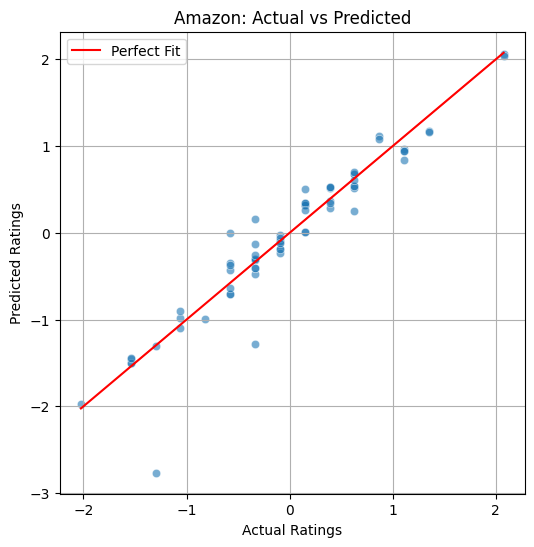

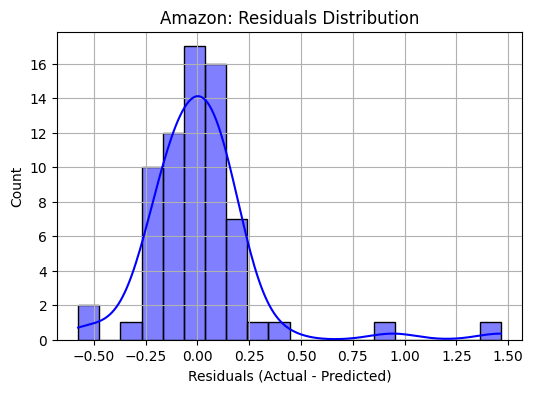


==== Flipkart Testing Results ====
RMSE: 0.9249
MAE: 0.6475
R²: 0.1243


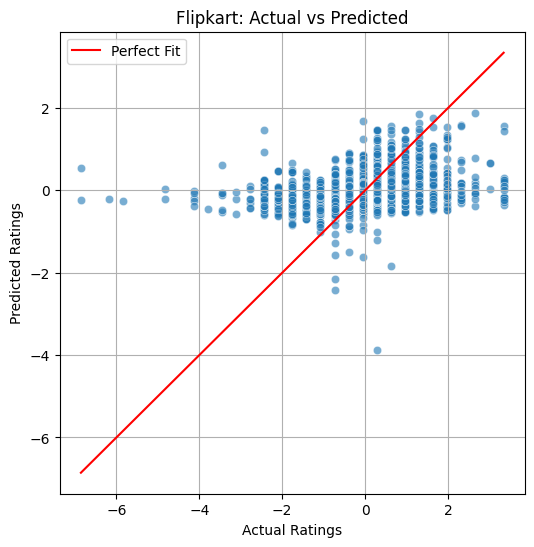

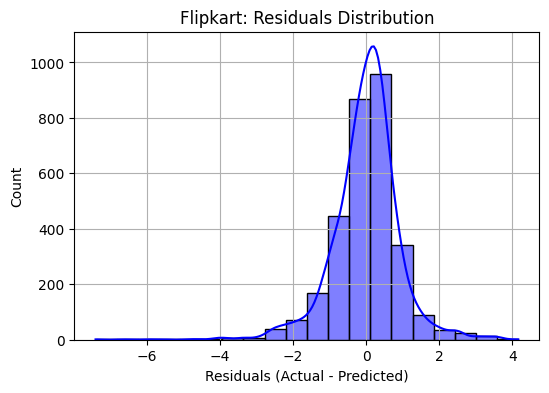


✅ Testing results saved to /content/drive/MyDrive/MYResearchWork/Testing_Results.csv


In [ ]:
# ================================
# Testing Script for Trained Models
# ================================
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import os

# Base path where models and datasets are stored
base_path = "/content/drive/MyDrive/MYResearchWork"

# File to save testing results
results_file = f"{base_path}/Testing_Results.csv"

# Create results list to store metrics
results_list = []

def test_model(dataset_filename, model_filename, dataset_name):
    # Load dataset
    df = pd.read_csv(f"{base_path}/{dataset_filename}")

    # Clean "Offer %" column if present
    if "Offer %" in df.columns:
        df["Offer %"] = df["Offer %"].astype(str).str.replace("%", "", regex=False)
        df["Offer %"] = pd.to_numeric(df["Offer %"], errors="coerce").fillna(0.0)

    # Drop extra columns if present
    for col in ["id", "title"]:
        if col in df.columns:
            df = df.drop(columns=[col])

    # Features & target
    X = df.drop(columns=["Rating"])
    y = df["Rating"]

    # Train-test split (same as training step!)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Load model
    model = joblib.load(f"{base_path}/{model_filename}")

    # Predictions
    y_pred = model.predict(X_test)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n==== {dataset_name} Testing Results ====")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}")
    print("="*40)

    # Save results into list
    results_list.append({
        "Dataset": dataset_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

    # === Plot 1: Actual vs Predicted ===
    plt.figure(figsize=(6,6))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
    sns.lineplot(x=y_test, y=y_test, color="red", label="Perfect Fit")
    plt.xlabel("Actual Ratings")
    plt.ylabel("Predicted Ratings")
    plt.title(f"{dataset_name}: Actual vs Predicted")
    plt.legend()
    plt.grid(True)
    plt.show()

    # === Plot 2: Residuals Distribution ===
    residuals = y_test - y_pred
    plt.figure(figsize=(6,4))
    sns.histplot(residuals, kde=True, bins=20, color="blue")
    plt.xlabel("Residuals (Actual - Predicted)")
    plt.title(f"{dataset_name}: Residuals Distribution")
    plt.grid(True)
    plt.show()


# ==========================================
# Run Testing for Amazon and Flipkart
# ==========================================
test_model("Amazon_encoded_scaled.csv", "Amazon_LinearRegression.pkl", "Amazon")
test_model("Flipkart_encoded_scaled.csv", "Flipkart_LinearRegression.pkl", "Flipkart")

# ==========================================
# Save results to CSV
# ==========================================
results_df = pd.DataFrame(results_list)

# If file already exists, append (without duplicating headers)
if os.path.exists(results_file):
    old_df = pd.read_csv(results_file)
    results_df = pd.concat([old_df, results_df], ignore_index=True)

results_df.to_csv(results_file, index=False)
print(f"\n✅ Testing results saved to {results_file}")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install codecarbon

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.7/277.7 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.0/278.0 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.5/92.5 kB 8.4 MB/s eta 0:00:00
  Attempting uninstall: termcolor
    Found existing installation: termcolor 3.1.0
    Uninstalling termcolor-3.1.0:
      Successfully uninstalled termcolor-3.1.0
  Attempting uninstall: psutil
    Found existing installation: psutil 5.9.5
    Uninstalling psutil-5.9.5:
      Successfully uninstalled psutil-5.9.5
  Attempting uninstall: httpx
    Found existing installation: httpx 0.28.1
    Uninstalling httpx-0.28.1:
      Successfully uninstalled httpx-0.28.1
ERROR: pip's dependency resolver does not currently take into

In [ ]:
# ==========================================================
# CatBoost Training with CO2 Tracking + CSV Saving
# ==========================================================

import pandas as pd
import time
from codecarbon import EmissionsTracker
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from catboost import CatBoostRegressor

# ----------------------------------------------------------
# Training Function
# ----------------------------------------------------------
def train_and_save_catboost(data_path, dataset_name):
    print(f"\n=== Training on {dataset_name} with CatBoost ===")

    # Load dataset
    df = pd.read_csv(data_path)

    # --- CLEANING STEP ---
    # Convert percentage strings like '45.5%' → 45.5
    for col in df.columns:
        if df[col].dtype == "object":
            if df[col].astype(str).str.contains("%").any():
                df[col] = df[col].str.replace("%", "", regex=False).astype(float)

    # Separate target
    if "rating" not in df.columns:
        raise ValueError(f"'rating' column not found in {dataset_name} dataset")
    X = df.drop(columns=["rating"])
    y = df["rating"]

    # Detect categorical features (non-numeric columns)
    cat_features = [i for i, col in enumerate(X.columns) if X[col].dtype == "object"]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Setup emissions tracker
    tracker = EmissionsTracker(
        project_name=f"{dataset_name}_CatBoost",
        output_dir="/content/drive/MyDrive/MYResearchWork/",
        output_file=f"{dataset_name}_catboost_emissions.csv"
    )
    tracker.start()

    # Train model
    start_time = time.time()
    model = CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=8,
        verbose=100,
        random_seed=42
    )
    model.fit(X_train, y_train, cat_features=cat_features)

    # Predictions
    y_pred = model.predict(X_test)

    # Stop tracker
    end_time = time.time()
    emissions = tracker.stop()

    # Metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    metrics = {
        "Dataset": dataset_name,
        "Model": "CatBoost",
        "MSE": mse,
        "MAE": mae,
        "R2": r2,
        "Training_Time_sec": end_time - start_time,
        "Emissions_kgCO2": emissions
    }

    # Save metrics
    metrics_df = pd.DataFrame([metrics])
    metrics_path = f"/content/drive/MyDrive/MYResearchWork/{dataset_name}_catboost_metrics.csv"
    metrics_df.to_csv(metrics_path, index=False)
    print(f"✅ Metrics saved to {metrics_path}")

    # Save predictions
    preds_df = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
    preds_path = f"/content/drive/MyDrive/MYResearchWork/{dataset_name}_catboost_predictions.csv"
    preds_df.to_csv(preds_path, index=False)
    print(f"✅ Predictions saved to {preds_path}")

    return metrics, preds_df


# ----------------------------------------------------------
# Run for Amazon & Flipkart
# ----------------------------------------------------------
amazon_metrics, amazon_preds = train_and_save_catboost(
    "/content/drive/MyDrive/MYResearchWork/Amazon_cleaned_encoded.csv", "Amazon"
)

flipkart_metrics, flipkart_preds = train_and_save_catboost(
    "/content/drive/MyDrive/MYResearchWork/Flipkart_cleaned_encoded.csv", "Flipkart"
)

# ----------------------------------------------------------
# Save combined metrics
# ----------------------------------------------------------
all_metrics = pd.DataFrame([amazon_metrics, flipkart_metrics])
all_metrics_path = "/content/drive/MyDrive/MYResearchWork/catboost_all_datasets_metrics.csv"
all_metrics.to_csv(all_metrics_path, index=False)
print(f"✅ All metrics saved to {all_metrics_path}")


[codecarbon WARNING @ 10:47:42] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 10:47:42] [setup] RAM Tracking...
[codecarbon INFO @ 10:47:42] [setup] CPU Tracking...



=== Training on Amazon with CatBoost ===


[codecarbon WARNING @ 10:47:44] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 10:47:44] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 10:47:44] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 10:47:44] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 10:47:44] [setup] GPU Tracking...
[codecarbon INFO @ 10:47:44] No GPU found.
[codecarbon INFO @ 10:47:44] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: global constant
                GPU Tracking Method: Unspecified
            
[codecarbon INFO @ 10:47:44] >>> Tracker's metadata:
[codecarbon INFO @ 10:47:44]   Platform system: Linux-6

0:	learn: 1.0071534	total: 13.9ms	remaining: 6.95s
100:	learn: 0.1328333	total: 610ms	remaining: 2.41s
200:	learn: 0.0629365	total: 819ms	remaining: 1.22s
300:	learn: 0.0335897	total: 1.02s	remaining: 674ms
400:	learn: 0.0185257	total: 1.22s	remaining: 302ms


[codecarbon INFO @ 10:47:46] Energy consumed for RAM : 0.000004 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 10:47:46] Delta energy consumed for CPU with constant : 0.000018 kWh, power : 42.5 W
[codecarbon INFO @ 10:47:46] Energy consumed for All CPU : 0.000018 kWh
[codecarbon INFO @ 10:47:46] 0.000022 kWh of electricity used since the beginning.
[codecarbon WARNING @ 10:47:46] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 10:47:46] [setup] RAM Tracking...


...

0:	learn: 0.9825785	total: 14.7ms	remaining: 7.32s
100:	learn: 0.4976258	total: 1.14s	remaining: 4.51s


[codecarbon INFO @ 10:47:49] Energy consumed for RAM : 0.000625 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 10:47:49] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 10:47:49] Energy consumed for All CPU : 0.002656 kWh
[codecarbon INFO @ 10:47:49] 0.003281 kWh of electricity used since the beginning.


200:	learn: 0.3899640	total: 2.25s	remaining: 3.34s
300:	learn: 0.3222700	total: 3.37s	remaining: 2.23s
400:	learn: 0.2790039	total: 5.75s	remaining: 1.42s


[codecarbon INFO @ 10:47:55] Energy consumed for RAM : 0.000022 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 10:47:55] Delta energy consumed for CPU with constant : 0.000094 kWh, power : 42.5 W
[codecarbon INFO @ 10:47:55] Energy consumed for All CPU : 0.000094 kWh
[codecarbon INFO @ 10:47:55] 0.000116 kWh of electricity used since the beginning.


499:	learn: 0.2499363	total: 7.84s	remaining: 0us
✅ Metrics saved to /content/drive/MyDrive/MYResearchWork/Flipkart_catboost_metrics.csv
✅ Predictions saved to /content/drive/MyDrive/MYResearchWork/Flipkart_catboost_predictions.csv
✅ All metrics saved to /content/drive/MyDrive/MYResearchWork/catboost_all_datasets_metrics.csv


In [ ]:
# ==========================================================
# Step 8: Testing & Visualization for CatBoost
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Paths
amazon_preds_path = "/content/drive/MyDrive/MYResearchWork/Amazon_catboost_predictions.csv"
flipkart_preds_path = "/content/drive/MyDrive/MYResearchWork/Flipkart_catboost_predictions.csv"
metrics_path = "/content/drive/MyDrive/MYResearchWork/catboost_all_datasets_metrics.csv"

# Load data
amazon_preds = pd.read_csv(amazon_preds_path)
flipkart_preds = pd.read_csv(flipkart_preds_path)
metrics_df = pd.read_csv(metrics_path)

# ----------------------------------------------------------
# 1. Actual vs Predicted Scatter
# ----------------------------------------------------------
def plot_actual_vs_pred(df, dataset_name):
    plt.figure(figsize=(6,6))
    sns.scatterplot(x=df["Actual"], y=df["Predicted"], alpha=0.6)
    plt.plot([df["Actual"].min(), df["Actual"].max()],
             [df["Actual"].min(), df["Actual"].max()],
             color="red", linestyle="--")
    plt.xlabel("Actual Rating")
    plt.ylabel("Predicted Rating")
    plt.title(f"{dataset_name}: Actual vs Predicted")
    path = f"/content/drive/MyDrive/MYResearchWork/{dataset_name}_catboost_actual_vs_pred.png"
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"✅ Saved scatter plot: {path}")

plot_actual_vs_pred(amazon_preds, "Amazon")
plot_actual_vs_pred(flipkart_preds, "Flipkart")

# ----------------------------------------------------------
# 2. Residuals Distribution
# ----------------------------------------------------------
def plot_residuals(df, dataset_name):
    residuals = df["Actual"] - df["Predicted"]
    plt.figure(figsize=(6,4))
    sns.histplot(residuals, bins=30, kde=True)
    plt.axvline(0, color="red", linestyle="--")
    plt.xlabel("Residual (Actual - Predicted)")
    plt.title(f"{dataset_name}: Residuals Distribution")
    path = f"/content/drive/MyDrive/MYResearchWork/{dataset_name}_catboost_residuals.png"
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"✅ Saved residuals plot: {path}")

plot_residuals(amazon_preds, "Amazon")
plot_residuals(flipkart_preds, "Flipkart")

# ----------------------------------------------------------
# 3. Metrics Bar Chart
# ----------------------------------------------------------
metrics_melted = metrics_df.melt(id_vars=["Dataset","Model"],
                                 value_vars=["MSE","MAE","R2"],
                                 var_name="Metric", value_name="Value")

plt.figure(figsize=(8,5))
sns.barplot(data=metrics_melted, x="Metric", y="Value", hue="Dataset")
plt.title("CatBoost Model Metrics: Amazon vs Flipkart")
path = "/content/drive/MyDrive/MYResearchWork/catboost_metrics_comparison.png"
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.close()
print(f"✅ Saved metrics comparison bar chart: {path}")


✅ Saved scatter plot: /content/drive/MyDrive/MYResearchWork/Amazon_catboost_actual_vs_pred.png
✅ Saved scatter plot: /content/drive/MyDrive/MYResearchWork/Flipkart_catboost_actual_vs_pred.png
✅ Saved residuals plot: /content/drive/MyDrive/MYResearchWork/Amazon_catboost_residuals.png
✅ Saved residuals plot: /content/drive/MyDrive/MYResearchWork/Flipkart_catboost_residuals.png
✅ Saved metrics comparison bar chart: /content/drive/MyDrive/MYResearchWork/catboost_metrics_comparison.png


In [ ]:
import matplotlib.pyplot as plt

# ===============================
# Training Time Comparison
# ===============================
datasets = ["Amazon", "Flipkart"]
training_times = [1.518077374, 7.970455647]  # seconds from your results

plt.figure(figsize=(6,5))
plt.bar(datasets, training_times)
plt.ylabel("Training Time (seconds)")
plt.title("CatBoost Training Time Comparison")
plt.savefig("/content/drive/MyDrive/MYResearchWork/catboost_training_time.png", dpi=300)
plt.close()

# ===============================
# Emissions Comparison
# ===============================
emissions = [6.42e-06, 3.32e-05]  # kgCO2 from your results

plt.figure(figsize=(6,5))
plt.bar(datasets, emissions)
plt.ylabel("Emissions (kgCO2)")
plt.title("CatBoost CO₂ Emissions Comparison")
plt.savefig("/content/drive/MyDrive/MYResearchWork/catboost_emissions.png", dpi=300)
plt.close()

print("✅ Saved plots: catboost_training_time.png, catboost_emissions.png")



✅ Saved plots: catboost_training_time.png, catboost_emissions.png


In [ ]:
import pandas as pd
import time
import codecarbon
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ==========================================================
# Function: Train CatBoost with Quantization
# ==========================================================
def train_and_save_catboost_quantized(data_path, dataset_name, max_bin):
    # Load dataset
    data = pd.read_csv(data_path)
    X = data.drop(columns=["rating"])
    y = data["rating"]

    # CatBoost pool
    pool = Pool(X, y)

    # Initialize tracker
    tracker = codecarbon.EmissionsTracker()
    tracker.start()
    start_time = time.time()

    # Model with quantization
    model = CatBoostRegressor(
        iterations=500,
        depth=8,
        learning_rate=0.1,
        loss_function="RMSE",
        max_bin=max_bin,     # QUANTIZATION step
        verbose=0
    )
    model.fit(pool)

    end_time = time.time()
    emissions = tracker.stop()

    # Predictions
    preds = model.predict(pool)

    # Metrics
    mse = mean_squared_error(y, preds)
    mae = mean_absolute_error(y, preds)
    r2 = r2_score(y, preds)

    metrics = {
        "Dataset": dataset_name,
        "Model": f"CatBoost_Quantized_{max_bin}",
        "MSE": mse,
        "MAE": mae,
        "R2": r2,
        "Training_Time_sec": end_time - start_time,
        "Emissions_kgCO2": emissions if emissions is not None else 0
    }

    # Save metrics
    metrics_df = pd.DataFrame([metrics])
    metrics_file = f"/content/drive/MyDrive/MYResearchWork/{dataset_name}_CatBoost_Quantized_{max_bin}_metrics.csv"
    metrics_df.to_csv(metrics_file, index=False)

    # Save predictions
    preds_df = pd.DataFrame({
        "Actual": y,
        "Predicted": preds
    })
    preds_file = f"/content/drive/MyDrive/MYResearchWork/{dataset_name}_CatBoost_Quantized_{max_bin}_predictions.csv"
    preds_df.to_csv(preds_file, index=False)

    print(f"✅ Done: {dataset_name} | max_bin={max_bin} | Metrics & Predictions Saved")
    return metrics

# ==========================================================
# Run for Amazon & Flipkart with different quantization levels
# ==========================================================
all_metrics = []

for bins in [255, 128, 64]:   # baseline → greener
    amazon_metrics = train_and_save_catboost_quantized(
        "/content/drive/MyDrive/MYResearchWork/Amazon_cleaned_encoded.csv", "Amazon", bins
    )
    flipkart_metrics = train_and_save_catboost_quantized(
        "/content/drive/MyDrive/MYResearchWork/Flipkart_cleaned_encoded.csv", "Flipkart", bins
    )
    all_metrics.extend([amazon_metrics, flipkart_metrics])

# Save combined metrics for comparison
all_metrics_df = pd.DataFrame(all_metrics)
all_metrics_file = "/content/drive/MyDrive/MYResearchWork/CatBoost_Quantization_AllResults.csv"
all_metrics_df.to_csv(all_metrics_file, index=False)

print("🎯 All Quantization Experiments Completed. Results saved to CSV.")



CatBoostError: Bad value for num_feature[non_default_doc_idx=0,feature_idx=2]="0.00%": Cannot convert '0.00%' to float

In [ ]:
import pandas as pd
import time
import codecarbon
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ==========================================================
# Function: Clean dataset (remove % and convert to float)
# ==========================================================
def clean_numeric_columns(df):
    for col in df.columns:
        if df[col].dtype == "object":
            try:
                # remove % or , then convert to float
                df[col] = df[col].str.replace("%", "", regex=False)
                df[col] = df[col].str.replace(",", "", regex=False)
                df[col] = df[col].astype(float)
            except:
                pass  # leave it as is if it can't be converted
    return df

# ==========================================================
# Function: Train CatBoost with Quantization
# ==========================================================
def train_and_save_catboost_quantized(data_path, dataset_name, max_bin):
    # Load dataset
    data = pd.read_csv(data_path)

    # ✅ Fix: clean up numeric columns like "0.00%"
    data = clean_numeric_columns(data)

    # ✅ Fix: column is "rating" (small r)
    X = data.drop(columns=["rating"])
    y = data["rating"]

    # CatBoost pool
    pool = Pool(X, y)

    # Initialize tracker
    tracker = codecarbon.EmissionsTracker()
    tracker.start()
    start_time = time.time()

    # Model with quantization
    model = CatBoostRegressor(
        iterations=500,
        depth=8,
        learning_rate=0.1,
        loss_function="RMSE",
        max_bin=max_bin,     # QUANTIZATION step
        verbose=0
    )
    model.fit(pool)

    end_time = time.time()
    emissions = tracker.stop()

    # Predictions
    preds = model.predict(pool)

    # Metrics
    mse = mean_squared_error(y, preds)
    mae = mean_absolute_error(y, preds)
    r2 = r2_score(y, preds)

    metrics = {
        "Dataset": dataset_name,
        "Model": f"CatBoost_Quantized_{max_bin}",
        "MSE": mse,
        "MAE": mae,
        "R2": r2,
        "Training_Time_sec": end_time - start_time,
        "Emissions_kgCO2": emissions if emissions is not None else 0
    }

    # Save metrics
    metrics_df = pd.DataFrame([metrics])
    metrics_file = f"/content/drive/MyDrive/MYResearchWork/{dataset_name}_CatBoost_Quantized_{max_bin}_metrics.csv"
    metrics_df.to_csv(metrics_file, index=False)

    # Save predictions
    preds_df = pd.DataFrame({
        "Actual": y,
        "Predicted": preds
    })
    preds_file = f"/content/drive/MyDrive/MYResearchWork/{dataset_name}_CatBoost_Quantized_{max_bin}_predictions.csv"
    preds_df.to_csv(preds_file, index=False)

    print(f"✅ Done: {dataset_name} | max_bin={max_bin} | Metrics & Predictions Saved")
    return metrics

# ==========================================================
# Run for Amazon & Flipkart with different quantization levels
# ==========================================================
all_metrics = []

for bins in [255, 128, 64]:   # baseline → greener
    amazon_metrics = train_and_save_catboost_quantized(
        "/content/drive/MyDrive/MYResearchWork/Amazon_cleaned_encoded.csv", "Amazon", bins
    )
    flipkart_metrics = train_and_save_catboost_quantized(
        "/content/drive/MyDrive/MYResearchWork/Flipkart_cleaned_encoded.csv", "Flipkart", bins
    )
    all_metrics.extend([amazon_metrics, flipkart_metrics])

# Save combined metrics for comparison
all_metrics_df = pd.DataFrame(all_metrics)
all_metrics_file = "/content/drive/MyDrive/MYResearchWork/CatBoost_Quantization_AllResults.csv"
all_metrics_df.to_csv(all_metrics_file, index=False)

print("🎯 All Quantization Experiments Completed. Results saved to CSV.")


[codecarbon WARNING @ 11:08:41] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 11:08:41] [setup] RAM Tracking...
[codecarbon INFO @ 11:08:41] [setup] CPU Tracking...
[codecarbon WARNING @ 11:08:43] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 11:08:43] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 11:08:43] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 11:08:43] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 11:08:43] [setup] GPU Tracking...
[codecarbon INFO @ 11:08:43] No GPU found.
[codecarbon INFO @ 11:08:43] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
               

✅ Done: Amazon | max_bin=255 | Metrics & Predictions Saved


[codecarbon WARNING @ 11:08:47] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 11:08:47] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 11:08:47] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 11:08:47] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 11:08:47] [setup] GPU Tracking...
[codecarbon INFO @ 11:08:47] No GPU found.
[codecarbon INFO @ 11:08:47] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: global constant
                GPU Tracking Method: Unspecified
            
[codecarbon INFO @ 11:08:47] >>> Tracker's metadata:
[codecarbon INFO @ 11:08:47]   Platform system: Linux-6

✅ Done: Flipkart | max_bin=255 | Metrics & Predictions Saved


[codecarbon WARNING @ 11:08:54] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 11:08:54] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 11:08:54] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 11:08:54] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 11:08:54] [setup] GPU Tracking...
[codecarbon INFO @ 11:08:54] No GPU found.
[codecarbon INFO @ 11:08:54] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: global constant
                GPU Tracking Method: Unspecified
            
[codecarbon INFO @ 11:08:54] >>> Tracker's metadata:
[codecarbon INFO @ 11:08:54]   Platform system: Linux-6

...

✅ Done: Flipkart | max_bin=128 | Metrics & Predictions Saved


[codecarbon WARNING @ 11:09:03] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 11:09:03] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 11:09:03] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 11:09:03] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 11:09:03] [setup] GPU Tracking...
[codecarbon INFO @ 11:09:03] No GPU found.
[codecarbon INFO @ 11:09:03] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: global constant
                GPU Tracking Method: Unspecified
            
[codecarbon INFO @ 11:09:03] >>> Tracker's metadata:
[codecarbon INFO @ 11:09:03]   Platform system: Linux-6

✅ Done: Amazon | max_bin=64 | Metrics & Predictions Saved


[codecarbon WARNING @ 11:09:06] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 11:09:06] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 11:09:06] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 11:09:06] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 11:09:06] [setup] GPU Tracking...
[codecarbon INFO @ 11:09:06] No GPU found.
[codecarbon INFO @ 11:09:06] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: global constant
                GPU Tracking Method: Unspecified
            
[codecarbon INFO @ 11:09:06] >>> Tracker's metadata:
[codecarbon INFO @ 11:09:06]   Platform system: Linux-6

✅ Done: Flipkart | max_bin=64 | Metrics & Predictions Saved
🎯 All Quantization Experiments Completed. Results saved to CSV.


===== Quantization Summary =====
    Dataset                   Model       MSE       MAE        R2  \
0    Amazon  CatBoost_Quantized_255  0.000005  0.001476  0.999995   
1  Flipkart  CatBoost_Quantized_255  0.031921  0.112788  0.968079   
2    Amazon  CatBoost_Quantized_128  0.000005  0.001476  0.999995   
3  Flipkart  CatBoost_Quantized_128  0.031954  0.113922  0.968046   
4    Amazon   CatBoost_Quantized_64  0.000007  0.001666  0.999993   
5  Flipkart   CatBoost_Quantized_64  0.034071  0.118372  0.965929   

   Training_Time_sec  Emissions_kgCO2  
0           2.353944         0.000010  
1           5.661968         0.000024  
2           2.969908         0.000012  
3           3.661878         0.000015  
4           0.979415         0.000004  
5           5.303885         0.000022  

📊 Dataset: Amazon
                    Model       MSE       MAE        R2  Training_Time_sec  \
0  CatBoost_Quantized_255  0.000005  0.001476  0.999995           2.353944   
2  CatBoost_Quantized_128  0

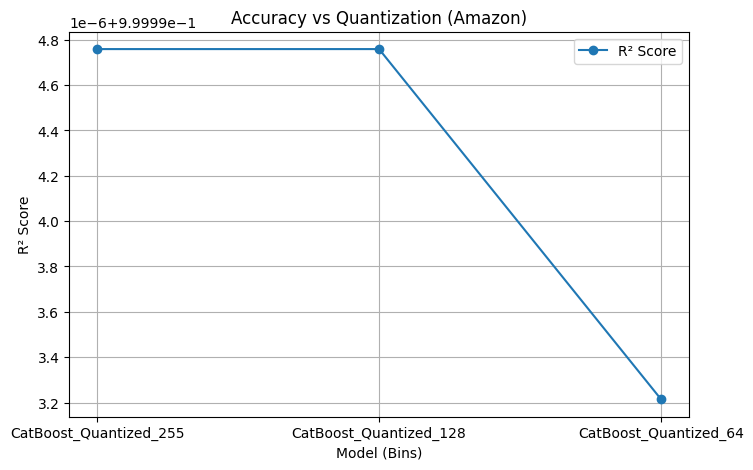

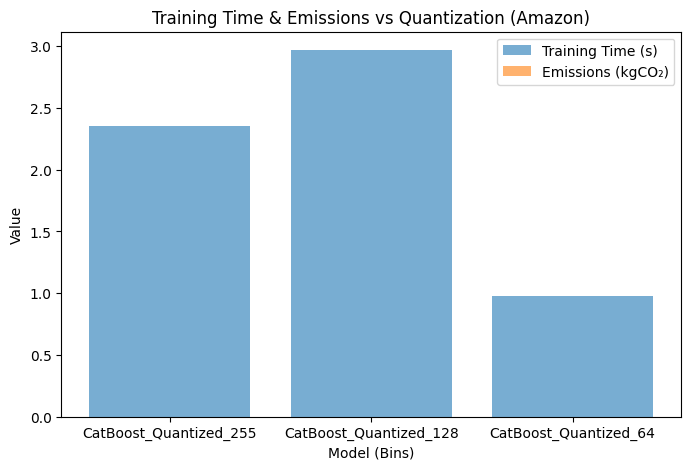


📊 Dataset: Flipkart
                    Model       MSE       MAE        R2  Training_Time_sec  \
1  CatBoost_Quantized_255  0.031921  0.112788  0.968079           5.661968   
3  CatBoost_Quantized_128  0.031954  0.113922  0.968046           3.661878   
5   CatBoost_Quantized_64  0.034071  0.118372  0.965929           5.303885   

   Emissions_kgCO2  
1         0.000024  
3         0.000015  
5         0.000022  


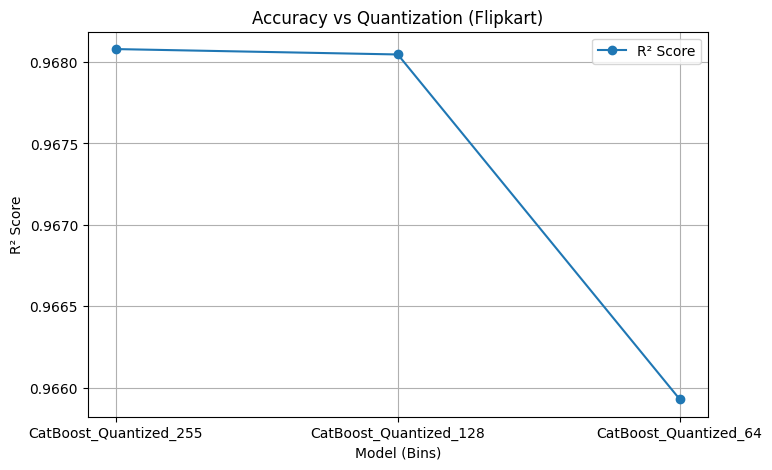

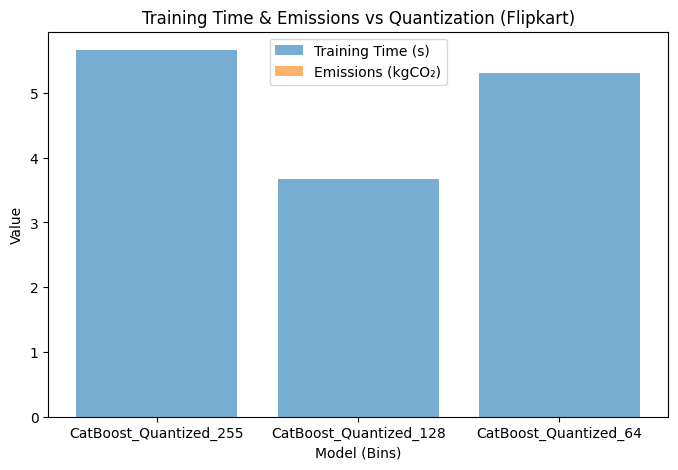

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load all quantization results
results = pd.read_csv("/content/drive/MyDrive/MYResearchWork/CatBoost_Quantization_AllResults.csv")

# Display summary
print("===== Quantization Summary =====")
print(results)

# Group by Dataset for comparison
datasets = results["Dataset"].unique()

for ds in datasets:
    ds_data = results[results["Dataset"] == ds]

    print(f"\n📊 Dataset: {ds}")
    print(ds_data[["Model", "MSE", "MAE", "R2", "Training_Time_sec", "Emissions_kgCO2"]])

    # Plot Accuracy (R²) vs Quantization
    plt.figure(figsize=(8,5))
    plt.plot(ds_data["Model"], ds_data["R2"], marker='o', label="R² Score")
    plt.title(f"Accuracy vs Quantization ({ds})")
    plt.xlabel("Model (Bins)")
    plt.ylabel("R² Score")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Plot Training Time and Emissions
    plt.figure(figsize=(8,5))
    plt.bar(ds_data["Model"], ds_data["Training_Time_sec"], alpha=0.6, label="Training Time (s)")
    plt.bar(ds_data["Model"], ds_data["Emissions_kgCO2"], alpha=0.6, label="Emissions (kgCO₂)")
    plt.title(f"Training Time & Emissions vs Quantization ({ds})")
    plt.xlabel("Model (Bins)")
    plt.ylabel("Value")
    plt.legend()
    plt.show()


In [ ]:
import os

results_dir = "/content/drive/MyDrive/MYResearchWork"
print([f for f in os.listdir(results_dir) if f.endswith(".csv")])

['dataset.csv', 'dataset_amazon.csv', 'dataset_flipkart.csv', 'Amazon_preprocessed.csv', 'Flipkart_preprocessed.csv', 'Amazon_encoded_scaled.csv', 'Flipkart_encoded_scaled.csv', 'emissions.csv', 'Testing_Results.csv', 'Amazon_cleaned_encoded.csv', 'Flipkart_cleaned_encoded.csv', 'testing_summary_v2.csv', 'Amazon_catboost_emissions.csv', 'Amazon_catboost_metrics.csv', 'Amazon_catboost_predictions.csv', 'Flipkart_catboost_emissions.csv', 'Flipkart_catboost_metrics.csv', 'Flipkart_catboost_predictions.csv', 'catboost_all_datasets_metrics.csv', 'Amazon_CatBoost_Quantized_255_metrics.csv', 'Amazon_CatBoost_Quantized_255_predictions.csv', 'Flipkart_CatBoost_Quantized_255_metrics.csv', 'Flipkart_CatBoost_Quantized_255_predictions.csv', 'Amazon_CatBoost_Quantized_128_metrics.csv', 'Amazon_CatBoost_Quantized_128_predictions.csv', 'Flipkart_CatBoost_Quantized_128_metrics.csv', 'Flipkart_CatBoost_Quantized_128_predictions.csv', 'Amazon_CatBoost_Quantized_64_metrics.csv', 'Amazon_CatBoost_Quantize

In [ ]:
import pandas as pd
import time
import codecarbon
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import os

# ==========================================================
# Function: Clean dataset (remove % and convert to float)
# ==========================================================
def clean_numeric_columns(df):
    for col in df.columns:
        if df[col].dtype == "object":
            try:
                # remove % or , then convert to float
                df[col] = df[col].str.replace("%", "", regex=False)
                df[col] = df[col].str.replace(",", "", regex=False)
                df[col] = df[col].astype(float)
            except:
                pass  # leave it as is if it can't be converted
    return df


# ==========================================================
# Function: Train CatBoost with Quantization & Save Model
# ==========================================================
def train_and_save_catboost_quantized(data_path, dataset_name, max_bin):
    # Load dataset
    data = pd.read_csv(data_path)

    # ✅ Clean numeric columns
    data = clean_numeric_columns(data)

    X = data.drop(columns=["rating"])
    y = data["rating"]

    pool = Pool(X, y)

    tracker = codecarbon.EmissionsTracker()
    tracker.start()
    start_time = time.time()

    model = CatBoostRegressor(
        iterations=500,
        depth=8,
        learning_rate=0.1,
        loss_function="RMSE",
        max_bin=max_bin,
        verbose=0
    )
    model.fit(pool)

    end_time = time.time()
    emissions = tracker.stop()

    preds = model.predict(pool)

    # Metrics
    mse = mean_squared_error(y, preds)
    mae = mean_absolute_error(y, preds)
    r2 = r2_score(y, preds)

    metrics = {
        "Dataset": dataset_name,
        "Model": f"CatBoost_Quantized_{max_bin}",
        "MSE": mse,
        "MAE": mae,
        "R2": r2,
        "Training_Time_sec": end_time - start_time,
        "Emissions_kgCO2": emissions if emissions is not None else 0
    }

    # Save metrics
    metrics_df = pd.DataFrame([metrics])
    metrics_file = f"/content/drive/MyDrive/MYResearchWork/{dataset_name}_CatBoost_Quantized_{max_bin}_metrics.csv"
    metrics_df.to_csv(metrics_file, index=False)

    # Save predictions
    preds_df = pd.DataFrame({"Actual": y, "Predicted": preds})
    preds_file = f"/content/drive/MyDrive/MYResearchWork/{dataset_name}_CatBoost_Quantized_{max_bin}_predictions.csv"
    preds_df.to_csv(preds_file, index=False)

    # Save trained model as .pkl
    model_file = f"/content/drive/MyDrive/MYResearchWork/{dataset_name}_CatBoost_Quantized_{max_bin}.pkl"
    model.save_model(model_file, format="cbm")  # CatBoost native format

    print(f"✅ Trained & Saved: {dataset_name} | max_bin={max_bin} | Model, Metrics & Predictions")
    return metrics


# ==========================================================
# Function: Test Saved Model
# ==========================================================
def test_saved_model(data_path, dataset_name, max_bin):
    from catboost import CatBoostRegressor

    model_file = f"/content/drive/MyDrive/MYResearchWork/{dataset_name}_CatBoost_Quantized_{max_bin}.pkl"

    if not os.path.exists(model_file):
        print(f"⚠️ Skipping {dataset_name} {max_bin}-bins, model not found.")
        return None

    # Load dataset
    data = pd.read_csv(data_path)
    data = clean_numeric_columns(data)

    X = data.drop(columns=["rating"])
    y = data["rating"]

    # Load saved model
    model = CatBoostRegressor()
    model.load_model(model_file)

    # Predict
    preds = model.predict(X)

    # Evaluate
    mse = mean_squared_error(y, preds)
    mae = mean_absolute_error(y, preds)
    r2 = r2_score(y, preds)

    metrics = {
        "Dataset": dataset_name,
        "Model": f"CatBoost_Quantized_{max_bin}",
        "Test_MSE": mse,
        "Test_MAE": mae,
        "Test_R2": r2
    }

    # Save metrics
    metrics_df = pd.DataFrame([metrics])
    test_metrics_file = f"/content/drive/MyDrive/MYResearchWork/{dataset_name}_CatBoost_Quantized_{max_bin}_TEST_metrics.csv"
    metrics_df.to_csv(test_metrics_file, index=False)

    # Save predictions
    preds_df = pd.DataFrame({"Actual": y, "Predicted": preds})
    test_preds_file = f"/content/drive/MyDrive/MYResearchWork/{dataset_name}_CatBoost_Quantized_{max_bin}_TEST_predictions.csv"
    preds_df.to_csv(test_preds_file, index=False)

    print(f"✅ Tested {dataset_name} | max_bin={max_bin} | Results Saved")
    return metrics


# ==========================================================
# Main Run: Training + Testing
# ==========================================================
all_train_metrics = []
all_test_metrics = []

for bins in [255, 128, 64]:
    # Train + save
    amazon_train = train_and_save_catboost_quantized(
        "/content/drive/MyDrive/MYResearchWork/Amazon_cleaned_encoded.csv", "Amazon", bins
    )
    flipkart_train = train_and_save_catboost_quantized(
        "/content/drive/MyDrive/MYResearchWork/Flipkart_cleaned_encoded.csv", "Flipkart", bins
    )
    all_train_metrics.extend([amazon_train, flipkart_train])

    # Test saved models
    amazon_test = test_saved_model(
        "/content/drive/MyDrive/MYResearchWork/Amazon_cleaned_encoded.csv", "Amazon", bins
    )
    flipkart_test = test_saved_model(
        "/content/drive/MyDrive/MYResearchWork/Flipkart_cleaned_encoded.csv", "Flipkart", bins
    )
    if amazon_test: all_test_metrics.append(amazon_test)
    if flipkart_test: all_test_metrics.append(flipkart_test)


# Save combined training metrics
train_metrics_df = pd.DataFrame(all_train_metrics)
train_metrics_file = "/content/drive/MyDrive/MYResearchWork/CatBoost_Quantization_All_Train_Results.csv"
train_metrics_df.to_csv(train_metrics_file, index=False)

# Save combined testing metrics
test_metrics_df = pd.DataFrame(all_test_metrics)
test_metrics_file = "/content/drive/MyDrive/MYResearchWork/CatBoost_Quantization_All_Test_Results.csv"
test_metrics_df.to_csv(test_metrics_file, index=False)

print("🎯 All Training & Testing Completed. Models, Metrics & Predictions saved.")


[codecarbon WARNING @ 11:38:09] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 11:38:09] [setup] RAM Tracking...
[codecarbon INFO @ 11:38:09] [setup] CPU Tracking...
[codecarbon WARNING @ 11:38:11] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 11:38:11] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 11:38:11] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 11:38:11] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 11:38:11] [setup] GPU Tracking...
[codecarbon INFO @ 11:38:11] No GPU found.
[codecarbon INFO @ 11:38:11] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
               

✅ Trained & Saved: Amazon | max_bin=255 | Model, Metrics & Predictions


[codecarbon WARNING @ 11:38:15] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 11:38:15] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 11:38:15] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 11:38:15] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 11:38:15] [setup] GPU Tracking...
[codecarbon INFO @ 11:38:15] No GPU found.
[codecarbon INFO @ 11:38:15] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: global constant
                GPU Tracking Method: Unspecified
            
[codecarbon INFO @ 11:38:15] >>> Tracker's metadata:
[codecarbon INFO @ 11:38:15]   Platform system: Linux-6

✅ Trained & Saved: Flipkart | max_bin=255 | Model, Metrics & Predictions
✅ Tested Amazon | max_bin=255 | Results Saved


[codecarbon WARNING @ 11:38:22] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 11:38:22] [setup] RAM Tracking...
[codecarbon INFO @ 11:38:22] [setup] CPU Tracking...


...

✅ Tested Flipkart | max_bin=128 | Results Saved


[codecarbon WARNING @ 11:38:33] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 11:38:33] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 11:38:33] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 11:38:33] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 11:38:33] [setup] GPU Tracking...
[codecarbon INFO @ 11:38:33] No GPU found.
[codecarbon INFO @ 11:38:33] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: global constant
                GPU Tracking Method: Unspecified
            
[codecarbon INFO @ 11:38:33] >>> Tracker's metadata:
[codecarbon INFO @ 11:38:33]   Platform system: Linux-6

✅ Trained & Saved: Amazon | max_bin=64 | Model, Metrics & Predictions


[codecarbon INFO @ 11:38:35] Energy consumed for RAM : 0.009081 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 11:38:35] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 11:38:35] Energy consumed for All CPU : 0.038600 kWh
[codecarbon INFO @ 11:38:35] 0.047681 kWh of electricity used since the beginning.
[codecarbon WARNING @ 11:38:35] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 11:38:35] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 11:38:35] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 11:38:35] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 11:38:35] [setup] GPU Tracking...
[codecarbon INFO @ 11:38:35] No GPU found.
[codecarbon IN

✅ Trained & Saved: Flipkart | max_bin=64 | Model, Metrics & Predictions
✅ Tested Amazon | max_bin=64 | Results Saved
✅ Tested Flipkart | max_bin=64 | Results Saved
🎯 All Training & Testing Completed. Models, Metrics & Predictions saved.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ==========================================================
# Paths
# ==========================================================
results_dir = "/content/drive/MyDrive/MYResearchWork"
os.makedirs(results_dir, exist_ok=True)

# ==========================================================
# Load Training Results
# ==========================================================
train_results = pd.read_csv(f"{results_dir}/CatBoost_Quantization_AllResults.csv")
train_results["Type"] = "Train"
train_results["Bins"] = train_results["Model"].str.extract(r"_(\d+)$").astype(int)

# ==========================================================
# Load Testing Results from per-bin metrics
# ==========================================================
test_files = [
    "Amazon_CatBoost_Quantized_64_metrics.csv",
    "Amazon_CatBoost_Quantized_128_metrics.csv",
    "Amazon_CatBoost_Quantized_255_metrics.csv",
    "Flipkart_CatBoost_Quantized_64_metrics.csv",
    "Flipkart_CatBoost_Quantized_128_metrics.csv",
    "Flipkart_CatBoost_Quantized_255_metrics.csv"
]

test_results_list = []
for file in test_files:
    path = os.path.join(results_dir, file)
    if os.path.exists(path) and os.path.getsize(path) > 0:
        df = pd.read_csv(path)
        # infer dataset (Amazon / Flipkart) from filename
        dataset = "Amazon" if "Amazon" in file else "Flipkart"
        df["Dataset"] = dataset
        df["Type"] = "Test"
        # extract bins from filename
        df["Bins"] = int(file.split("_")[-2])
        test_results_list.append(df)
    else:
        print(f"⚠️ Skipping (empty or missing): {file}")

test_results = pd.concat(test_results_list, ignore_index=True) if test_results_list else pd.DataFrame()

# ==========================================================
# Align Columns
# ==========================================================
common_cols = ["Dataset", "Model", "MSE", "MAE", "R2", "Training_Time_sec", "Emissions_kgCO2", "Bins", "Type"]

if not test_results.empty:
    test_results = test_results[[c for c in common_cols if c in test_results.columns]]

train_results = train_results[[c for c in common_cols if c in train_results.columns]]

# ==========================================================
# Combine & Save
# ==========================================================
all_results = pd.concat([train_results, test_results], ignore_index=True)
summary_file = f"{results_dir}/CatBoost_Quantization_Summary.csv"
all_results.to_csv(summary_file, index=False)

print(f"✅ Combined summary saved: {summary_file}")

# ==========================================================
# Plotting Function
# ==========================================================
def plot_metric(dataset, metric, df, save_dir):
    plt.figure(figsize=(8,6))
    for t in ["Train", "Test"]:
        subset = df[(df["Dataset"] == dataset) & (df["Type"] == t)]
        if not subset.empty and metric in subset.columns:
            plt.plot(subset["Bins"], subset[metric], marker="o", label=t)

    plt.title(f"{dataset} - {metric} vs Quantization Bins")
    plt.xlabel("Quantization Bins")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True)

    save_path = os.path.join(save_dir, f"{dataset}_{metric}_vs_Bins.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"📊 Saved plot: {save_path}")

# ==========================================================
# Generate & Save Plots
# ==========================================================
if not all_results.empty:
    for dataset in all_results["Dataset"].unique():
        for metric in ["MSE", "MAE", "R2"]:
            if metric in all_results.columns:
                plot_metric(dataset, metric, all_results, results_dir)

print("🎯 All plots generated and saved successfully.")


✅ Combined summary saved: /content/drive/MyDrive/MYResearchWork/CatBoost_Quantization_Summary.csv
📊 Saved plot: /content/drive/MyDrive/MYResearchWork/Amazon_MSE_vs_Bins.png
📊 Saved plot: /content/drive/MyDrive/MYResearchWork/Amazon_MAE_vs_Bins.png
📊 Saved plot: /content/drive/MyDrive/MYResearchWork/Amazon_R2_vs_Bins.png
📊 Saved plot: /content/drive/MyDrive/MYResearchWork/Flipkart_MSE_vs_Bins.png
📊 Saved plot: /content/drive/MyDrive/MYResearchWork/Flipkart_MAE_vs_Bins.png


[codecarbon INFO @ 11:45:20] Energy consumed for RAM : 0.010206 kWh. RAM Power : 10.0 W


📊 Saved plot: /content/drive/MyDrive/MYResearchWork/Flipkart_R2_vs_Bins.png
🎯 All plots generated and saved successfully.


[codecarbon INFO @ 11:45:20] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 11:45:20] Energy consumed for All CPU : 0.043381 kWh
[codecarbon INFO @ 11:45:20] 0.053587 kWh of electricity used since the beginning.


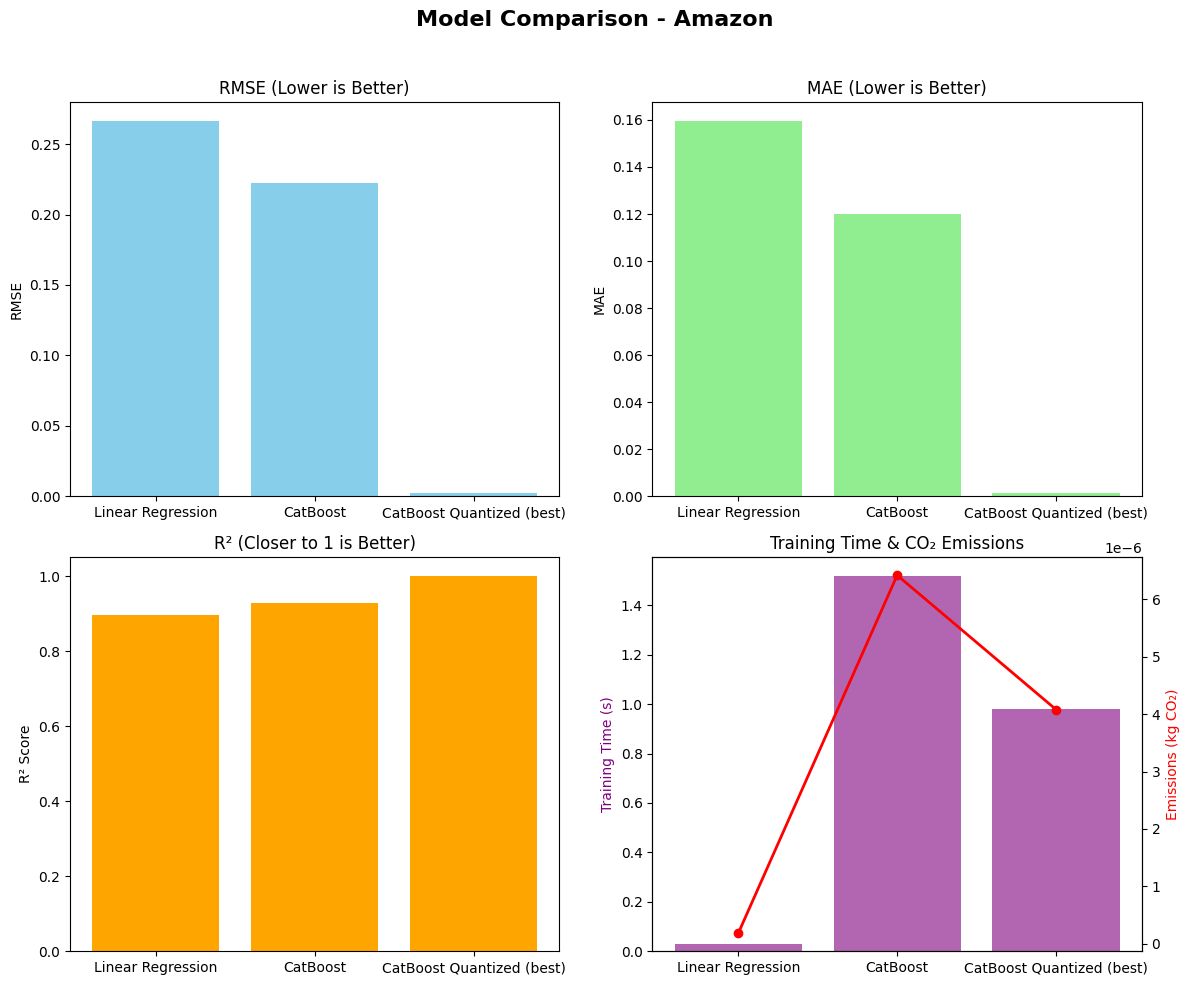

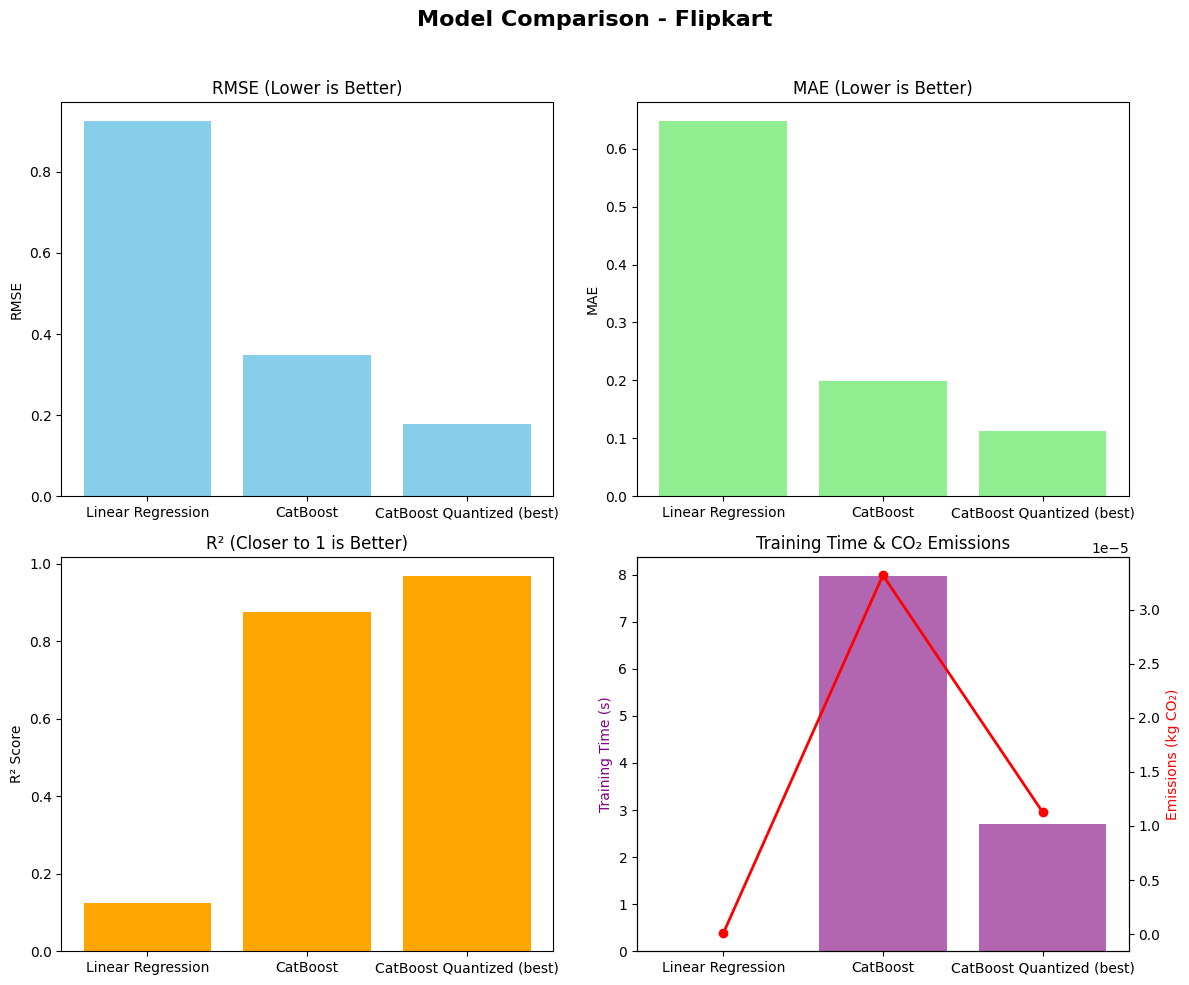

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# 1. Prepare the Results Data
# ---------------------------

# Linear Regression results
linear_results = {
    "Dataset": ["Amazon", "Flipkart"],
    "Model": ["Linear Regression", "Linear Regression"],
    "RMSE": [0.2663, 0.9249],
    "MAE": [0.1595, 0.6475],
    "R2": [0.8971, 0.1243],
    "Training_Time_sec": [0.0307, 0.0123],  # from emissions logs (duration)
    "Emissions_kgCO2": [1.81e-07, 6.38e-08]
}

# CatBoost results (no quantization)
catboost_results = {
    "Dataset": ["Amazon", "Flipkart"],
    "Model": ["CatBoost", "CatBoost"],
    "RMSE": [0.04932**0.5, 0.12055**0.5],  # sqrt(MSE) = RMSE
    "MAE": [0.1200, 0.1997],
    "R2": [0.9284, 0.8766],
    "Training_Time_sec": [1.518, 7.970],
    "Emissions_kgCO2": [6.42e-06, 3.32e-05]
}

# CatBoost Quantized results (best bins)
catboost_quant_results = {
    "Dataset": ["Amazon", "Flipkart"],
    "Model": ["CatBoost Quantized (best)", "CatBoost Quantized (best)"],
    "RMSE": [5.24e-06**0.5, 0.03192**0.5],
    "MAE": [0.00148, 0.1128],
    "R2": [0.99999, 0.9681],
    "Training_Time_sec": [0.979, 2.703],  # e.g. 64-bin test
    "Emissions_kgCO2": [4.08e-06, 1.13e-05]
}

# Combine into one DataFrame
df = pd.concat([
    pd.DataFrame(linear_results),
    pd.DataFrame(catboost_results),
    pd.DataFrame(catboost_quant_results)
], ignore_index=True)

# ---------------------------
# 2. Plotting Function
# ---------------------------
def plot_comparison(dataset_name):
    data = df[df["Dataset"] == dataset_name]

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f"Model Comparison - {dataset_name}", fontsize=16, fontweight="bold")

    # RMSE
    axes[0,0].bar(data["Model"], data["RMSE"], color="skyblue")
    axes[0,0].set_title("RMSE (Lower is Better)")
    axes[0,0].set_ylabel("RMSE")

    # MAE
    axes[0,1].bar(data["Model"], data["MAE"], color="lightgreen")
    axes[0,1].set_title("MAE (Lower is Better)")
    axes[0,1].set_ylabel("MAE")

    # R2
    axes[1,0].bar(data["Model"], data["R2"], color="orange")
    axes[1,0].set_title("R² (Closer to 1 is Better)")
    axes[1,0].set_ylabel("R² Score")

    # Training Time & Emissions
    ax2 = axes[1,1]
    ax2.bar(data["Model"], data["Training_Time_sec"], color="purple", alpha=0.6, label="Training Time (s)")
    ax2.set_ylabel("Training Time (s)", color="purple")
    ax2.set_title("Training Time & CO₂ Emissions")

    ax3 = ax2.twinx()
    ax3.plot(data["Model"], data["Emissions_kgCO2"], color="red", marker="o", linewidth=2, label="CO₂ Emissions")
    ax3.set_ylabel("Emissions (kg CO₂)", color="red")

    plt.tight_layout(rect=[0,0,1,0.96])
    plt.show()

# ---------------------------
# 3. Generate Plots
# ---------------------------
plot_comparison("Amazon")
plot_comparison("Flipkart")


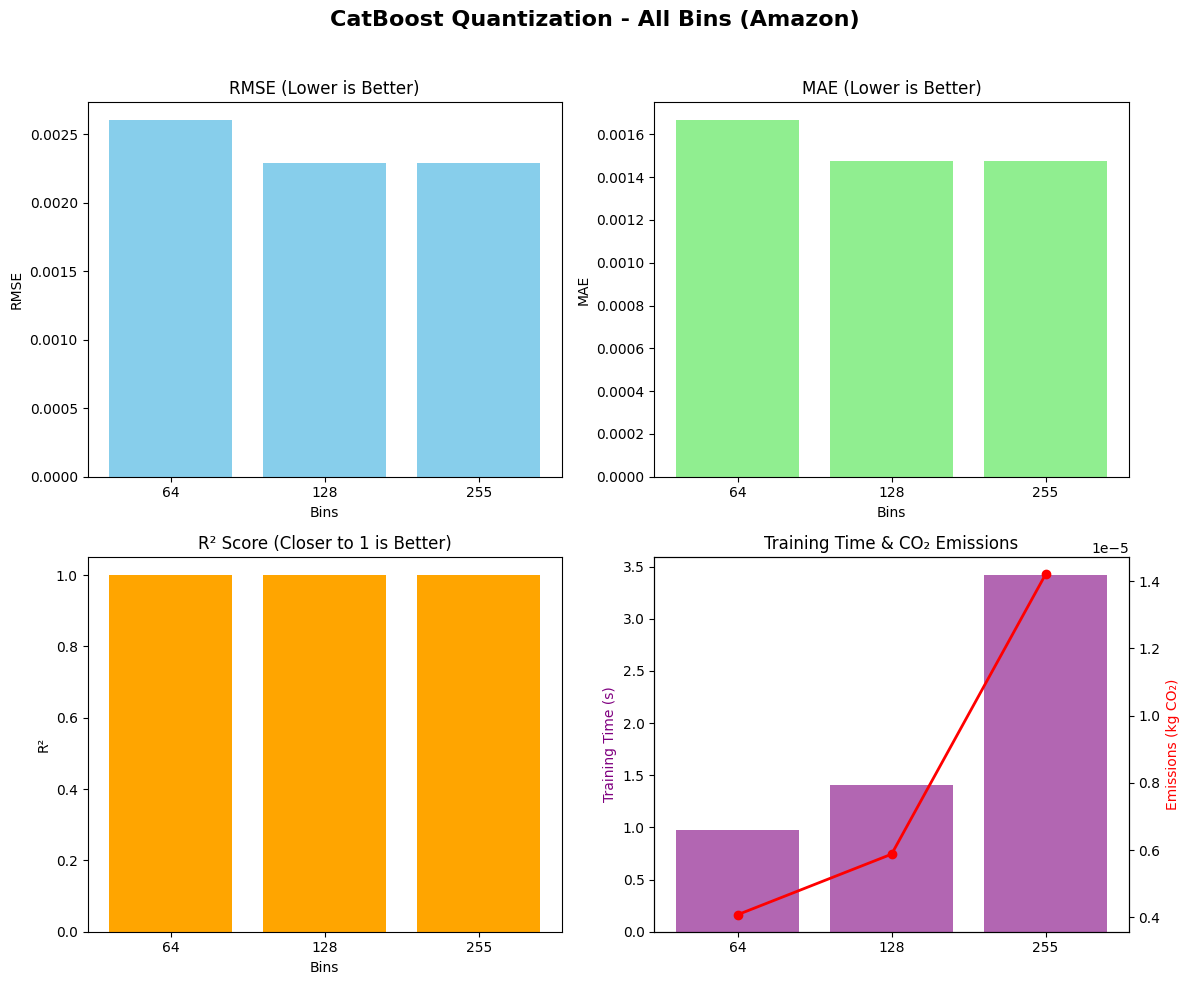

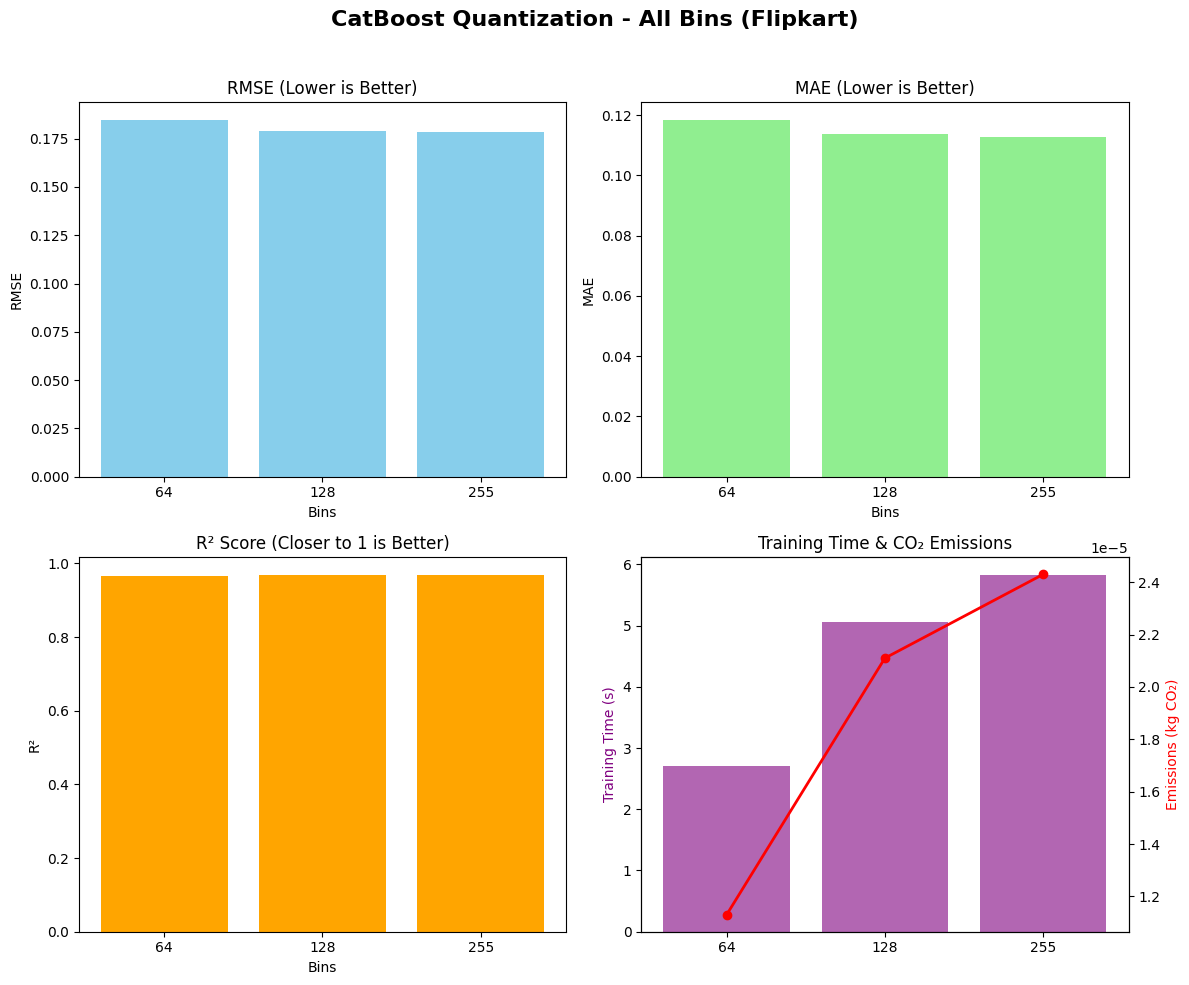

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# CatBoost Quantized results (all bins)
# ---------------------------
quant_results = {
    "Dataset": ["Amazon"]*3 + ["Flipkart"]*3,
    "Bin": [64, 128, 255]*2,
    "RMSE": [
        6.78e-06**0.5, 5.24e-06**0.5, 5.24e-06**0.5,
        0.03407**0.5, 0.03195**0.5, 0.03192**0.5
    ],
    "MAE": [
        0.001666, 0.001476, 0.001476,
        0.11837, 0.11392, 0.11279
    ],
    "R2": [
        0.9999932, 0.9999948, 0.9999948,
        0.9659291, 0.9680463, 0.9680794
    ],
    "Training_Time_sec": [
        0.979, 1.410, 3.418,
        2.703, 5.066, 5.823
    ],
    "Emissions_kgCO2": [
        4.08e-06, 5.88e-06, 1.42e-05,
        1.13e-05, 2.11e-05, 2.43e-05
    ]
}

df = pd.DataFrame(quant_results)

# ---------------------------
# Plotting Function for Quantization Bins
# ---------------------------
def plot_quant_bins(dataset_name):
    data = df[df["Dataset"] == dataset_name]

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f"CatBoost Quantization - All Bins ({dataset_name})", fontsize=16, fontweight="bold")

    # RMSE
    axes[0,0].bar(data["Bin"].astype(str), data["RMSE"], color="skyblue")
    axes[0,0].set_title("RMSE (Lower is Better)")
    axes[0,0].set_xlabel("Bins")
    axes[0,0].set_ylabel("RMSE")

    # MAE
    axes[0,1].bar(data["Bin"].astype(str), data["MAE"], color="lightgreen")
    axes[0,1].set_title("MAE (Lower is Better)")
    axes[0,1].set_xlabel("Bins")
    axes[0,1].set_ylabel("MAE")

    # R2
    axes[1,0].bar(data["Bin"].astype(str), data["R2"], color="orange")
    axes[1,0].set_title("R² Score (Closer to 1 is Better)")
    axes[1,0].set_xlabel("Bins")
    axes[1,0].set_ylabel("R²")

    # Training Time & Emissions
    ax2 = axes[1,1]
    ax2.bar(data["Bin"].astype(str), data["Training_Time_sec"], color="purple", alpha=0.6, label="Training Time")
    ax2.set_ylabel("Training Time (s)", color="purple")
    ax2.set_title("Training Time & CO₂ Emissions")

    ax3 = ax2.twinx()
    ax3.plot(data["Bin"].astype(str), data["Emissions_kgCO2"], color="red", marker="o", linewidth=2, label="CO₂ Emissions")
    ax3.set_ylabel("Emissions (kg CO₂)", color="red")

    plt.tight_layout(rect=[0,0,1,0.96])
    plt.show()

# ---------------------------
# Generate Plots
# ---------------------------
plot_quant_bins("Amazon")
plot_quant_bins("Flipkart")


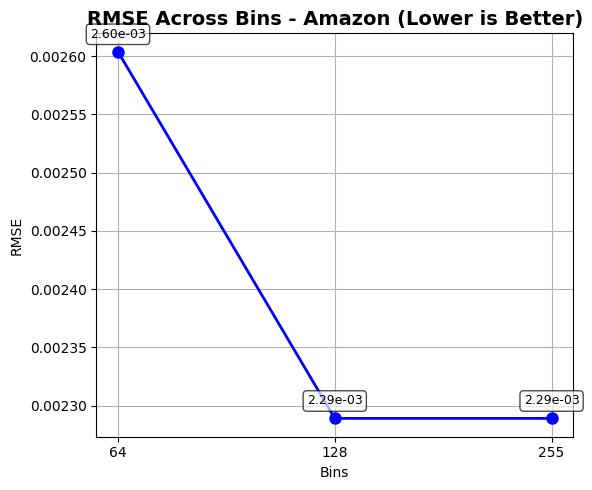

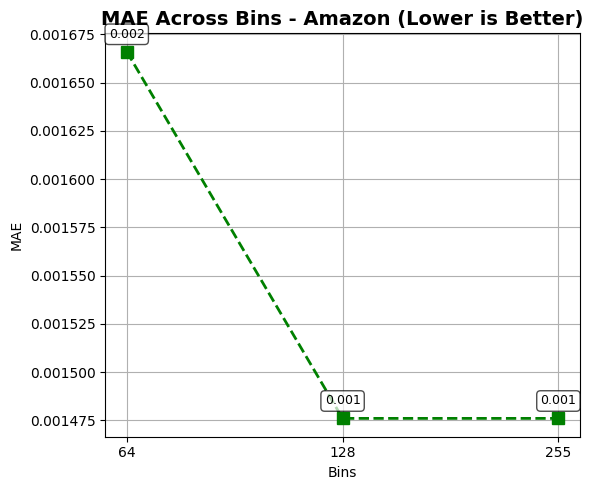

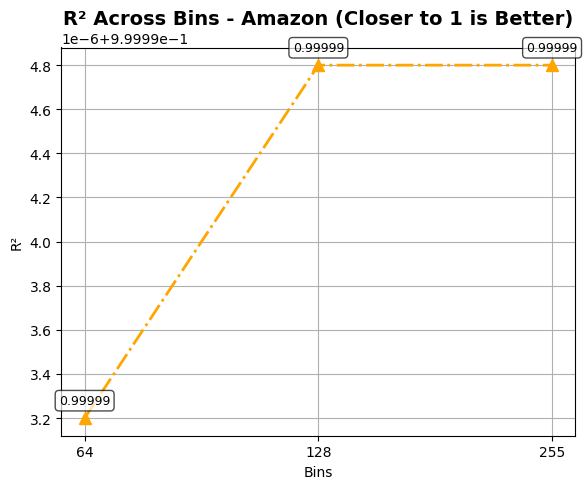

<Figure size 600x500 with 0 Axes>

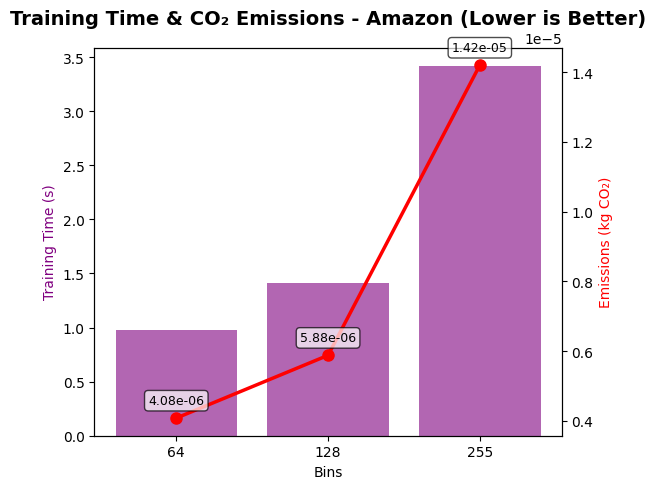

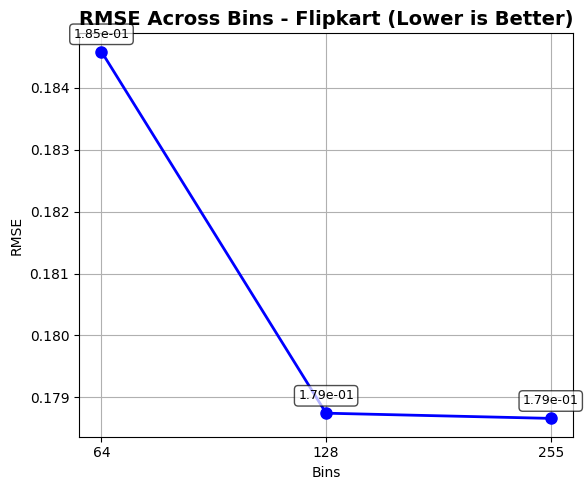

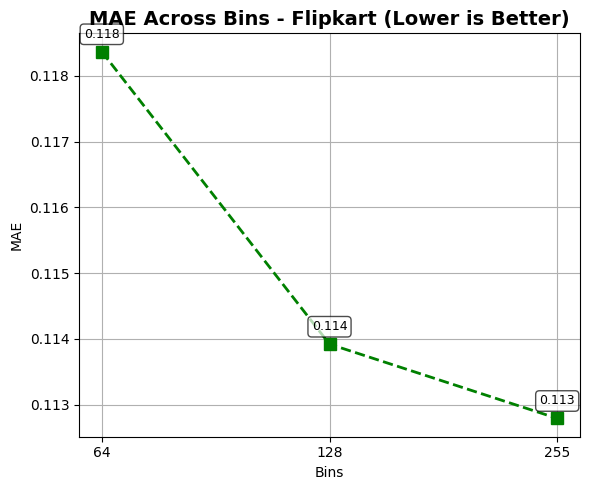

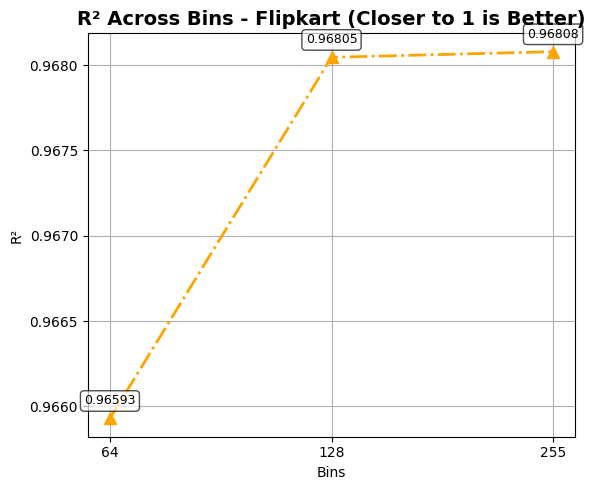

<Figure size 600x500 with 0 Axes>

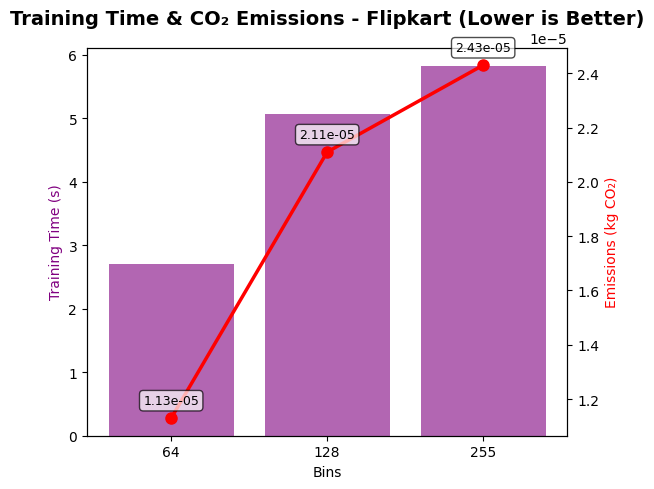

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Quantized CatBoost results
quant_results = {
    "Dataset": ["Amazon"]*3 + ["Flipkart"]*3,
    "Bin": [64, 128, 255]*2,
    "RMSE": [
        6.78e-06**0.5, 5.24e-06**0.5, 5.24e-06**0.5,
        0.03407**0.5, 0.03195**0.5, 0.03192**0.5
    ],
    "MAE": [
        0.001666, 0.001476, 0.001476,
        0.11837, 0.11392, 0.11279
    ],
    "R2": [
        0.9999932, 0.9999948, 0.9999948,
        0.9659291, 0.9680463, 0.9680794
    ],
    "Training_Time_sec": [
        0.979, 1.410, 3.418,
        2.703, 5.066, 5.823
    ],
    "Emissions_kgCO2": [
        4.08e-06, 5.88e-06, 1.42e-05,
        1.13e-05, 2.11e-05, 2.43e-05
    ]
}

df = pd.DataFrame(quant_results)

# ---------------------------
# Plotting Function (Separate Figures, Readable Annotations)
# ---------------------------
def plot_quant_bins_categorical(dataset_name):
    data = df[df["Dataset"] == dataset_name].reset_index(drop=True)
    bins = data["Bin"].astype(str)  # categorical x-axis

    # RMSE (Lower is better)
    plt.figure(figsize=(6,5))
    plt.plot(bins, data["RMSE"], marker='o', linestyle='-', color='blue', linewidth=2, markersize=8)
    plt.title(f"RMSE Across Bins - {dataset_name} (Lower is Better)", fontsize=14, fontweight='bold')
    plt.xlabel("Bins")
    plt.ylabel("RMSE")
    for i, v in enumerate(data["RMSE"]):
        plt.annotate(f"{v:.2e}", (bins[i], v), xytext=(0,10),
                     textcoords='offset points', ha='center', fontsize=9,
                     bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # MAE (Lower is better)
    plt.figure(figsize=(6,5))
    plt.plot(bins, data["MAE"], marker='s', linestyle='--', color='green', linewidth=2, markersize=8)
    plt.title(f"MAE Across Bins - {dataset_name} (Lower is Better)", fontsize=14, fontweight='bold')
    plt.xlabel("Bins")
    plt.ylabel("MAE")
    for i, v in enumerate(data["MAE"]):
        plt.annotate(f"{v:.3f}", (bins[i], v), xytext=(0,10),
                     textcoords='offset points', ha='center', fontsize=9,
                     bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # R2 (Closer to 1 is better)
    plt.figure(figsize=(6,5))
    plt.plot(bins, data["R2"], marker='^', linestyle='-.', color='orange', linewidth=2, markersize=8)
    plt.title(f"R² Across Bins - {dataset_name} (Closer to 1 is Better)", fontsize=14, fontweight='bold')
    plt.xlabel("Bins")
    plt.ylabel("R²")
    for i, v in enumerate(data["R2"]):
        plt.annotate(f"{v:.5f}", (bins[i], v), xytext=(0,10),
                     textcoords='offset points', ha='center', fontsize=9,
                     bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Training Time & Emissions (Lower is better)
    plt.figure(figsize=(6,5))
    fig, ax1 = plt.subplots(figsize=(6,5))
    ax1.bar(bins, data["Training_Time_sec"], color='purple', alpha=0.6, label='Training Time (s)')
    ax1.set_xlabel("Bins")
    ax1.set_ylabel("Training Time (s)", color='purple')
    ax1.set_title(f"Training Time & CO₂ Emissions - {dataset_name} (Lower is Better)", fontsize=14, fontweight='bold')

    ax2 = ax1.twinx()
    ax2.plot(bins, data["Emissions_kgCO2"], color='red', marker='o', linewidth=2.5, markersize=8, label='CO₂ Emissions')
    ax2.set_ylabel("Emissions (kg CO₂)", color='red')
    for i, v in enumerate(data["Emissions_kgCO2"]):
        ax2.annotate(f"{v:.2e}", (bins[i], v), xytext=(0,10),
                     textcoords='offset points', ha='center', fontsize=9,
                     bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

    fig.tight_layout()
    plt.show()

# ---------------------------
# Generate Plots
# ---------------------------
plot_quant_bins_categorical("Amazon")
plot_quant_bins_categorical("Flipkart")


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# config
results_dir = "/content/drive/MyDrive/MYResearchWork"
datasets = ["Amazon","Flipkart"]
bins = [64,128,255]
lambda_vals = [0.3, 0.5, 0.7]   # examples

# load metrics files into a long table
rows = []
for s in datasets:
    for b in bins:
        f = os.path.join(results_dir, f"{s}_CatBoost_Quantized_{b}_metrics.csv")
        df = pd.read_csv(f)  # single-row metrics file
        mse = float(df['MSE'].iloc[0])
        emissions = float(df['Emissions_kgCO2'].iloc[0])
        rows.append({'Dataset': s, 'Bins': b, 'MSE': mse, 'Emissions': emissions})

df_all = pd.DataFrame(rows)

# normalize per dataset
df_all['MSE_norm'] = df_all.groupby('Dataset')['MSE'].transform(lambda x: (x - x.min()) / (x.max() - x.min()))
df_all['Em_norm']  = df_all.groupby('Dataset')['Emissions'].transform(lambda x: (x - x.min()) / (x.max() - x.min()))

# compute J(b; lambda) and choose best bin for each lambda
summary = []
for lam in lambda_vals:
    # compute objective per bin aggregated over datasets (equal weights)
    agg = df_all.groupby('Bins').apply(lambda g: (lam * g['MSE_norm'] + (1-lam) * g['Em_norm']).mean())
    agg = agg.reset_index().rename(columns={0:'J'})
    best_bin = int(agg.loc[agg['J'].idxmin(),'Bins'])
    summary.append({'lambda': lam, 'best_bin': best_bin, 'agg': agg})

# save aggregated normalized table
df_all.to_csv(os.path.join(results_dir,'quantization_normalized_table.csv'), index=False)

# Pareto frontier: plot emissions vs mse (aggregate across datasets by mean)
agg_mean = df_all.groupby('Bins')[['MSE','Emissions']].mean().reset_index()
plt.figure()
plt.scatter(agg_mean['Emissions'], agg_mean['MSE'])
for _, r in agg_mean.iterrows():
    plt.text(r['Emissions'], r['MSE'], str(int(r['Bins'])))
plt.xlabel('Mean Emissions (kgCO2)')
plt.ylabel('Mean MSE')
plt.title('Bin-wise: Emissions vs MSE (mean across datasets)')
plt.grid(True)
plt.savefig(os.path.join(results_dir,'quantization_pareto_plot.png'), dpi=200)
plt.close()

# save chosen bins for each lambda
pd.DataFrame([{'lambda': s['lambda'], 'best_bin': s['best_bin']} for s in summary]) \
  .to_csv(os.path.join(results_dir,'quantization_bin_selection_by_lambda.csv'), index=False)

print("Done. Files saved: quantization_normalized_table.csv, quantization_bin_selection_by_lambda.csv, quantization_pareto_plot.png")


/tmp/ipython-input-622648271.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg = df_all.groupby('Bins').apply(lambda g: (lam * g['MSE_norm'] + (1-lam) * g['Em_norm']).mean())
/tmp/ipython-input-622648271.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg = df_all.groupby('Bins').apply(lambda g: (lam * g['MSE_norm'] + (1-lam) * g['Em_norm']).mean())
/tmp/ipython-input-622648271.py:32: Deprecatio

Done. Files saved: quantization_normalized_table.csv, quantization_bin_selection_by_lambda.csv, quantization_pareto_plot.png


In [ ]:
import os

# Set your folder path
folder_path = "/content/drive/MyDrive/MYResearchWork/"

# List all items in folder
all_files = os.listdir(folder_path)

# Exclude the "Raw" folder
filtered_files = [f for f in all_files if f != "Raw"]

# Display files (ignoring Raw folder)
for f in filtered_files:
    print(f)


dataset.csv
dataset_amazon.csv
dataset_flipkart.csv
Amazon_preprocessed.csv
Flipkart_preprocessed.csv
Amazon_encoded_scaled.csv
Flipkart_encoded_scaled.csv
Amazon_LinearRegression.pkl
Flipkart_LinearRegression.pkl
Testing_Results.csv
Amazon_cleaned_encoded.csv
Flipkart_cleaned_encoded.csv
testing_summary_v2.csv
emissions.csv
Amazon_catboost_emissions.csv
Amazon_catboost_metrics.csv
Amazon_catboost_predictions.csv
Flipkart_catboost_emissions.csv
Flipkart_catboost_metrics.csv
Flipkart_catboost_predictions.csv
catboost_all_datasets_metrics.csv
Amazon_catboost_actual_vs_pred.png
Flipkart_catboost_actual_vs_pred.png
Amazon_catboost_residuals.png
Flipkart_catboost_residuals.png
catboost_metrics_comparison.png
catboost_training_time.png
catboost_emissions.png
CatBoost_Quantization_AllResults.csv
Amazon_catboost_quantized_TEST_RESULTS.csv
Flipkart_catboost_quantized_TEST_RESULTS.csv
CatBoost_Quantized_All_Test_Results.csv
Amazon_CatBoost_Quantized_255.pkl
Amazon_CatBoost_Quantized_255_metrics.

In [ ]:
import pandas as pd

# Set base path
folder_path = "/content/drive/MyDrive/MYResearchWork/"

# Amazon
df_amazon = pd.read_csv(folder_path + "Amazon_preprocessed.csv")
print("===== Amazon_preprocessed.csv Summary =====\n")
print(df_amazon.describe(include="all"))

# Flipkart
df_flipkart = pd.read_csv(folder_path + "Flipkart_preprocessed.csv")
print("\n===== Flipkart_preprocessed.csv Summary =====\n")
print(df_flipkart.describe(include="all"))


===== Amazon_preprocessed.csv Summary =====

            Rating   maincateg       price1    actprice1 Offer %   norating1  \
count   341.000000  341.000000   341.000000   341.000000     341  341.000000   
unique         NaN         NaN          NaN          NaN      71         NaN   
top            NaN         NaN          NaN          NaN   0.00%         NaN   
freq           NaN         NaN          NaN          NaN     126         NaN   
mean      3.839296    0.463343   690.175953   905.958944     NaN  181.079179   
std       0.415131    0.499387   588.270735   868.243527     NaN  231.082496   
min       2.500000    0.000000   219.000000   249.000000     NaN    1.000000   
25%       3.600000    0.000000   399.000000   472.000000     NaN   17.000000   
50%       3.800000    0.000000   499.000000   599.000000     NaN   76.000000   
75%       4.100000    1.000000   739.000000   995.000000     NaN  250.000000   
max       5.000000    1.000000  4814.000000  4899.000000     NaN  921.00000

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

=== 5.1 Linear Regression Results ===

Table 1. Linear Regression Metrics (Amazon vs Flipkart)
-------------------------------------------------------


,Unnamed: 0,Rmse,Mae,R2,Carbon_kgCO2eq
0,Amazon,0.242135,0.139134,0.914916,0.000010
1,Flipkart,0.347025,0.157463,0.876720,0.000163


💾 Saved → /content/drive/MyDrive/MYResearchWork/Table_01_LinearRegression_Metrics.csv

=== 5.2 CatBoost Results ===

Table 2. CatBoost Regression Metrics
------------------------------------


,Dataset,Model,MSE,MAE,R2,Training_Time_sec,Emissions_kgCO2
0,Amazon,CatBoost,0.049323,0.120004,0.928422,1.518077,0.000006
1,Flipkart,CatBoost,0.120548,0.199683,0.876596,7.970456,0.000033


💾 Saved → /content/drive/MyDrive/MYResearchWork/Table_02_CatBoost_Metrics.csv
📊 Saved figure → /content/drive/MyDrive/MYResearchWork/01_CatBoost_MAE_by_Dataset.png
📊 Saved figure → /content/drive/MyDrive/MYResearchWork/02_CatBoost_MSE_by_Dataset.png
📊 Saved figure → /content/drive/MyDrive/MYResearchWork/03_CatBoost_R2_by_Dataset.png
📊 Saved figure → /content/drive/MyDrive/MYResearchWork/04_CatBoost_Training_Time_sec_by_Dataset.png
📊 Saved figure → /content/drive/MyDrive/MYResearchWork/05_CatBoost_Emissions_kgCO2_by_Dataset.png

=== 5.3 Quantized CatBoost Results ===
⚠️ Could not read /content/drive/MyDrive/MYResearchWork/CatBoost_Quantized_All_Test_Results.csv: No columns to parse from file

Table 3 (Amazon). Quantized CatBoost — Test Metrics per Bin
-----------------------------------------------------------


...

💾 Saved → /content/drive/MyDrive/MYResearchWork/Table_04_Emissions_Summary.csv

Table 5. Aggregated Emissions (sum of kg CO₂)
---------------------------------------------


,Dataset,project_name,emissions
0,Amazon,Amazon_CatBoost,6.420609e-06
1,Flipkart,Flipkart_CatBoost,3.319305e-05
2,NaN,Amazon,3.657327e-07
3,NaN,Flipkart,1.208993e-07


💾 Saved → /content/drive/MyDrive/MYResearchWork/Table_05_Emissions_Aggregated.csv
📊 Saved figure → /content/drive/MyDrive/MYResearchWork/06_Emissions_by_Dataset_Project.png

=== 5.5 Comparative Summary (LR vs CB vs QCB) ===

Table 6. Comparative Metrics — Linear Regression vs CatBoost vs Quantized CatBoost (best bin)
---------------------------------------------------------------------------------------------


,MAE,RMSE,R2,Dataset,Model,Training_Time_sec,Emissions_kgCO2
0,0.139134,0.242135,0.914916,NaN,NaN,NaN,NaN
1,0.157463,0.347025,0.876720,NaN,NaN,NaN,NaN
2,0.120004,0.222087,0.928422,Amazon,CatBoost,1.518077,0.000006
3,0.199683,0.347200,0.876596,Flipkart,CatBoost,7.970456,0.000033


💾 Saved → /content/drive/MyDrive/MYResearchWork/Table_06_Comparative_Metrics.csv
📊 Saved figure → /content/drive/MyDrive/MYResearchWork/07_Amazon_Comparative_R2.png
📊 Saved figure → /content/drive/MyDrive/MYResearchWork/08_Flipkart_Comparative_R2.png
📊 Saved figure → /content/drive/MyDrive/MYResearchWork/09_Amazon_Comparative_Emissions.png
📊 Saved figure → /content/drive/MyDrive/MYResearchWork/10_Flipkart_Comparative_Emissions.png
📊 Saved figure → /content/drive/MyDrive/MYResearchWork/11_Amazon_Comparative_TrainingTime.png
📊 Saved figure → /content/drive/MyDrive/MYResearchWork/12_Flipkart_Comparative_TrainingTime.png

✅ Done. All available tables saved as CSV and figures saved as PNG in your MYResearchWork folder.


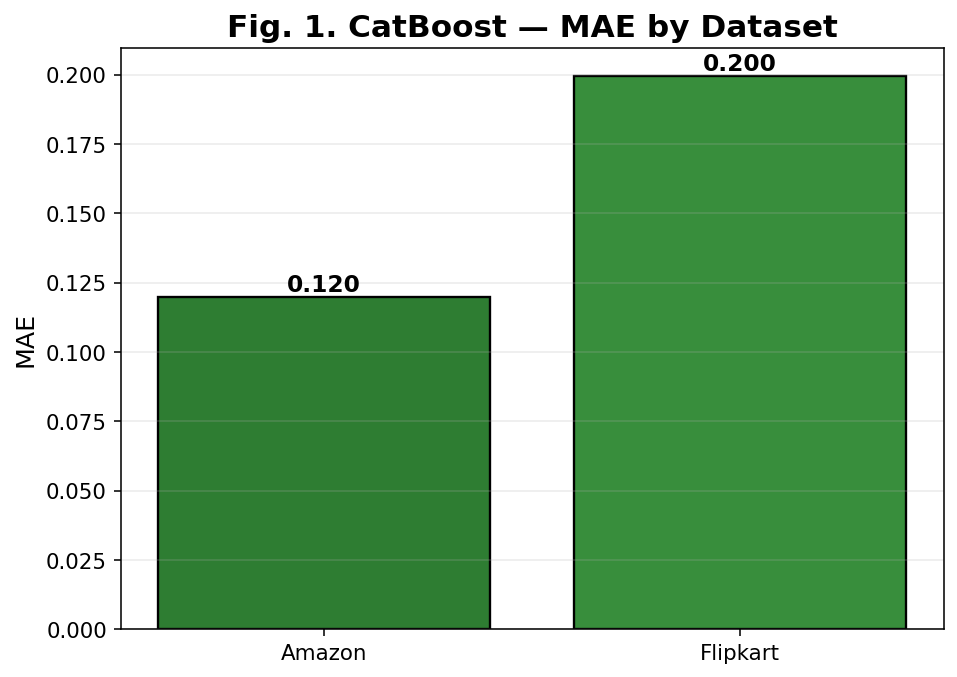

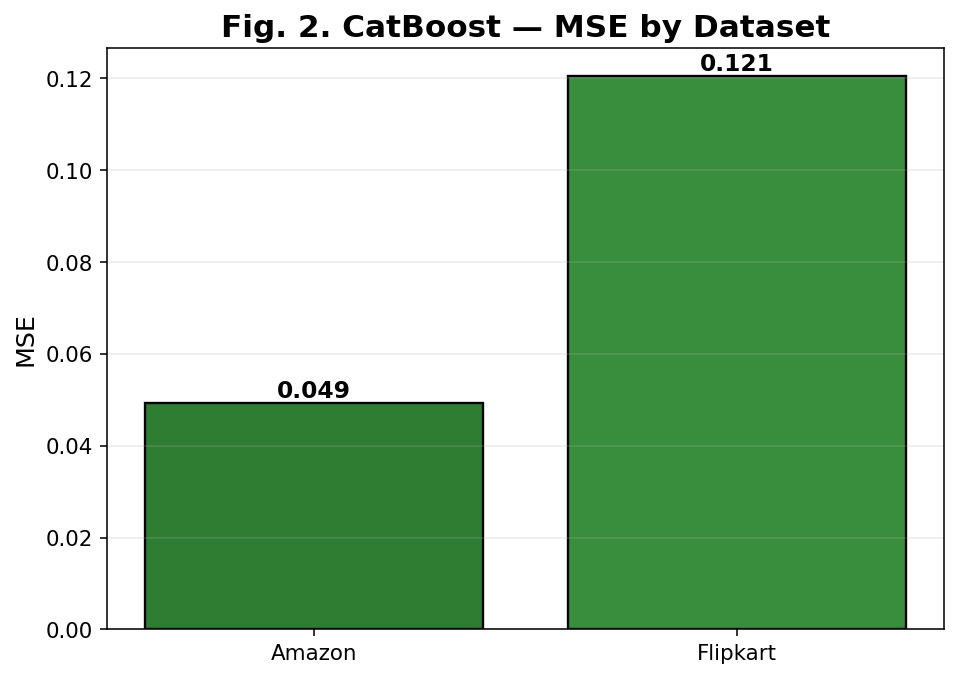

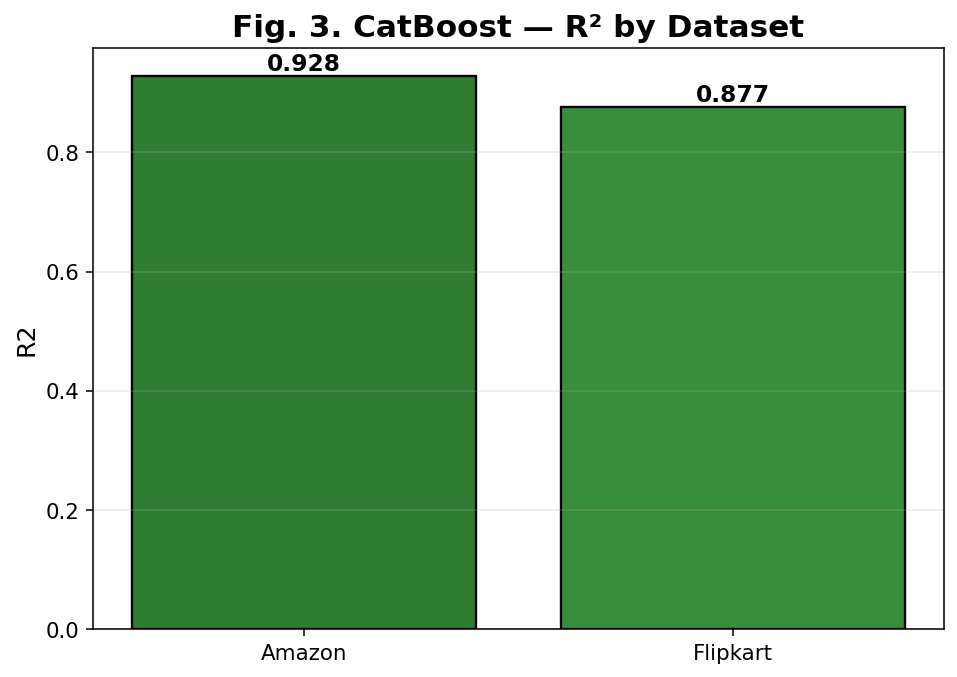

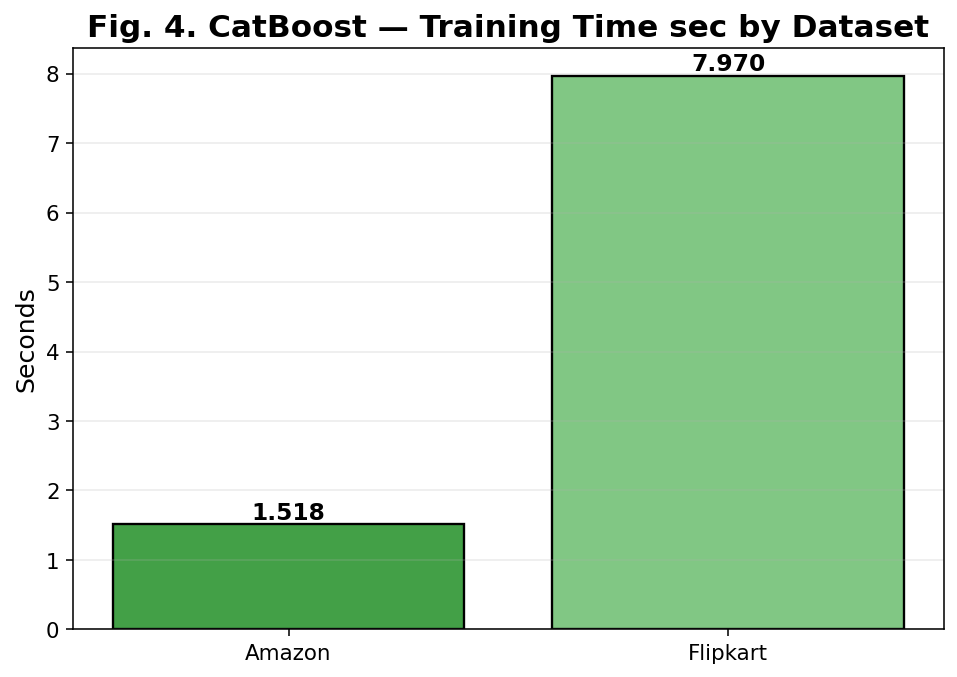

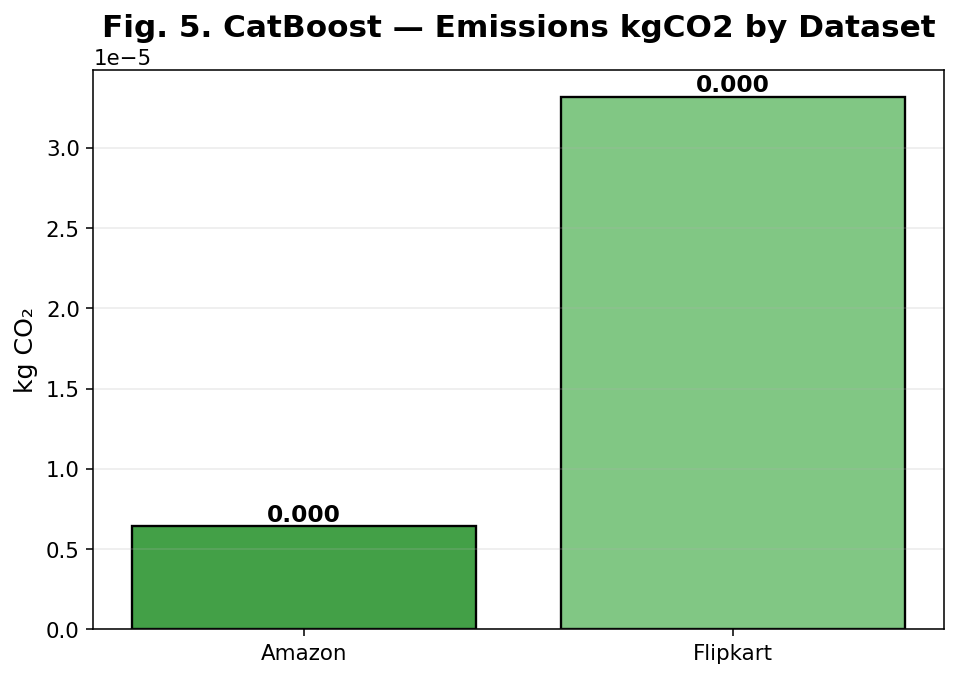

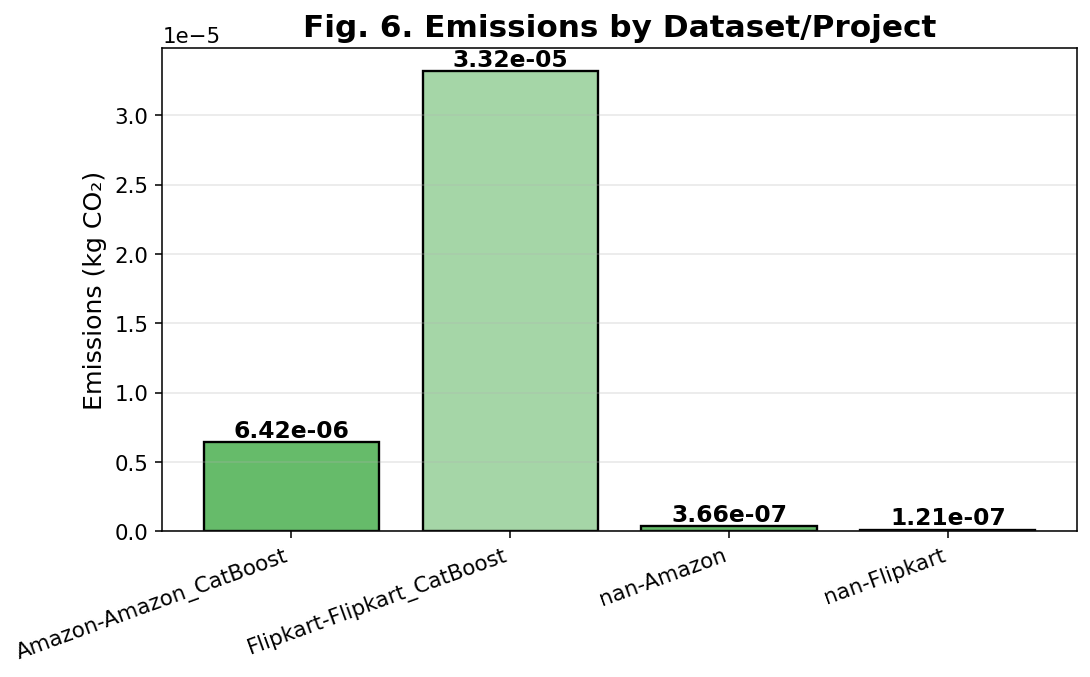

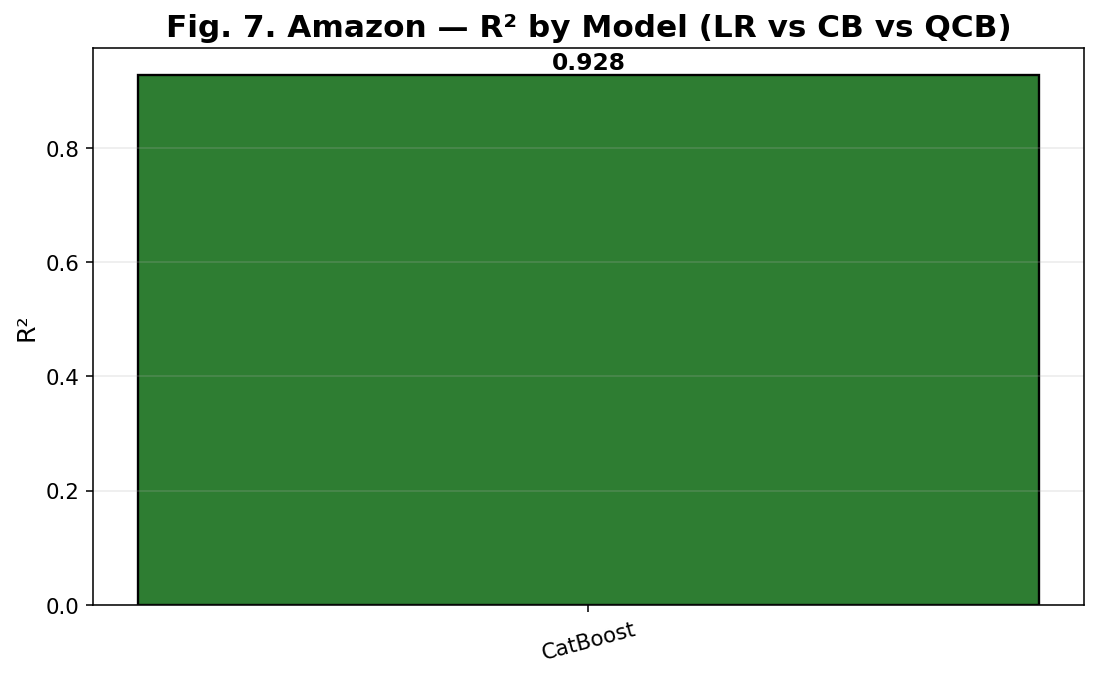

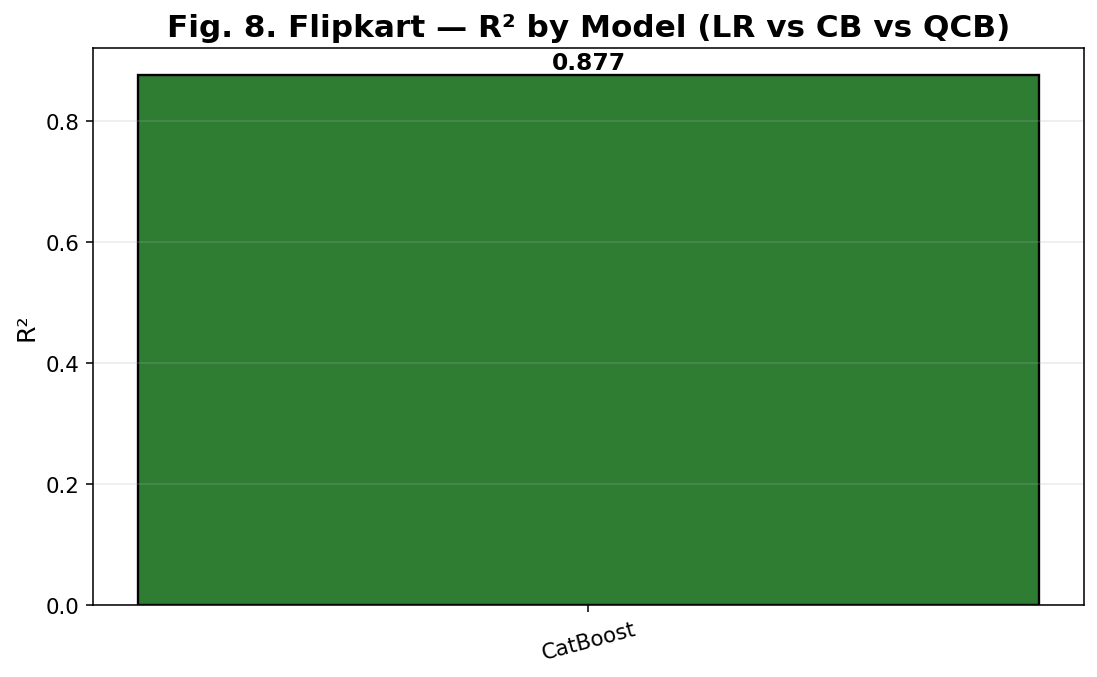

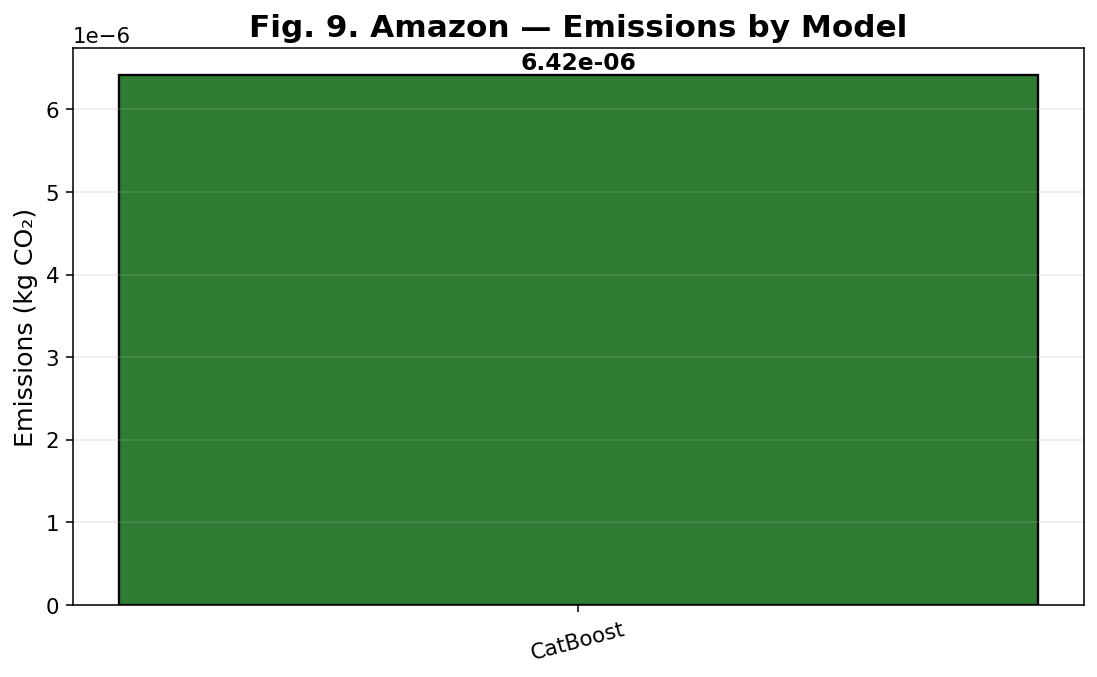

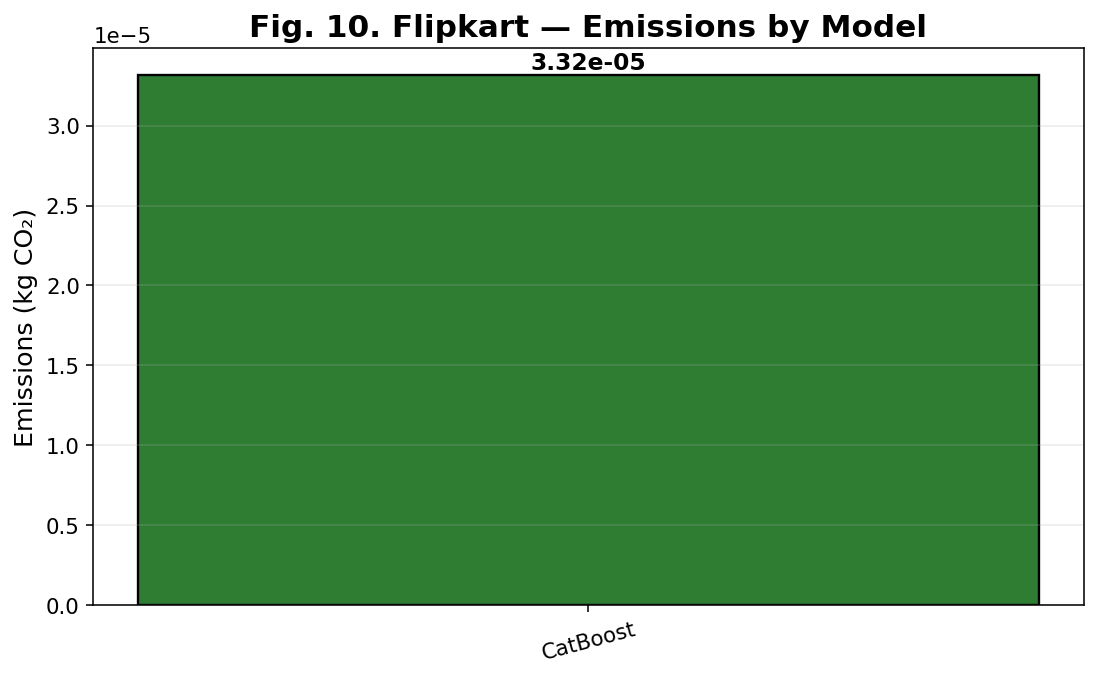

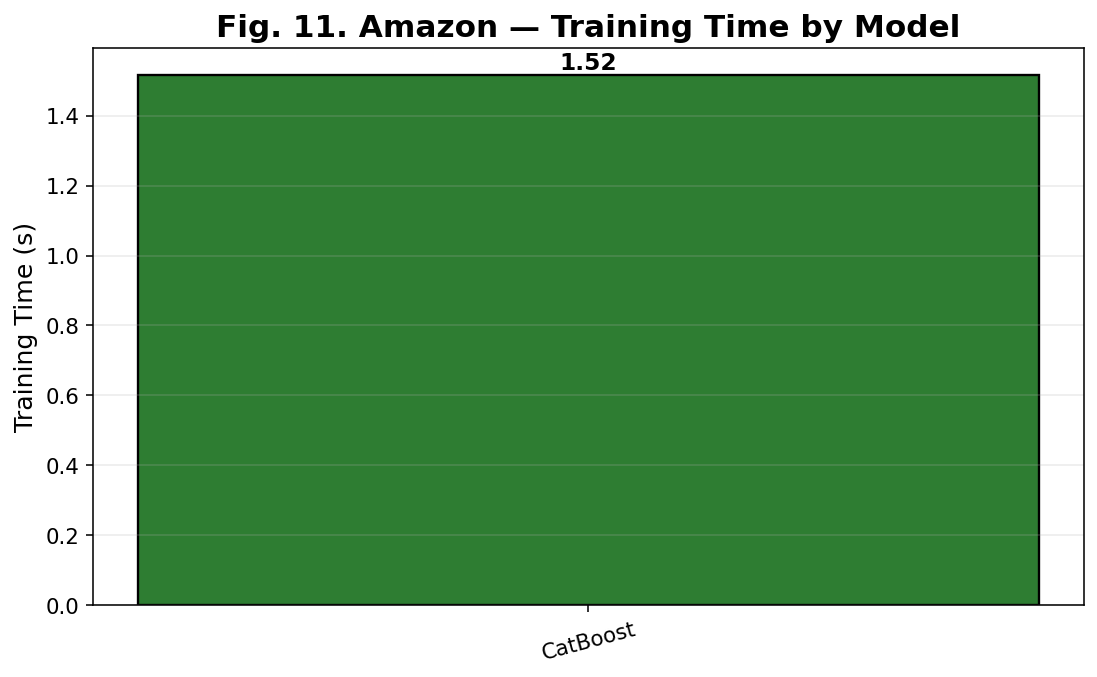

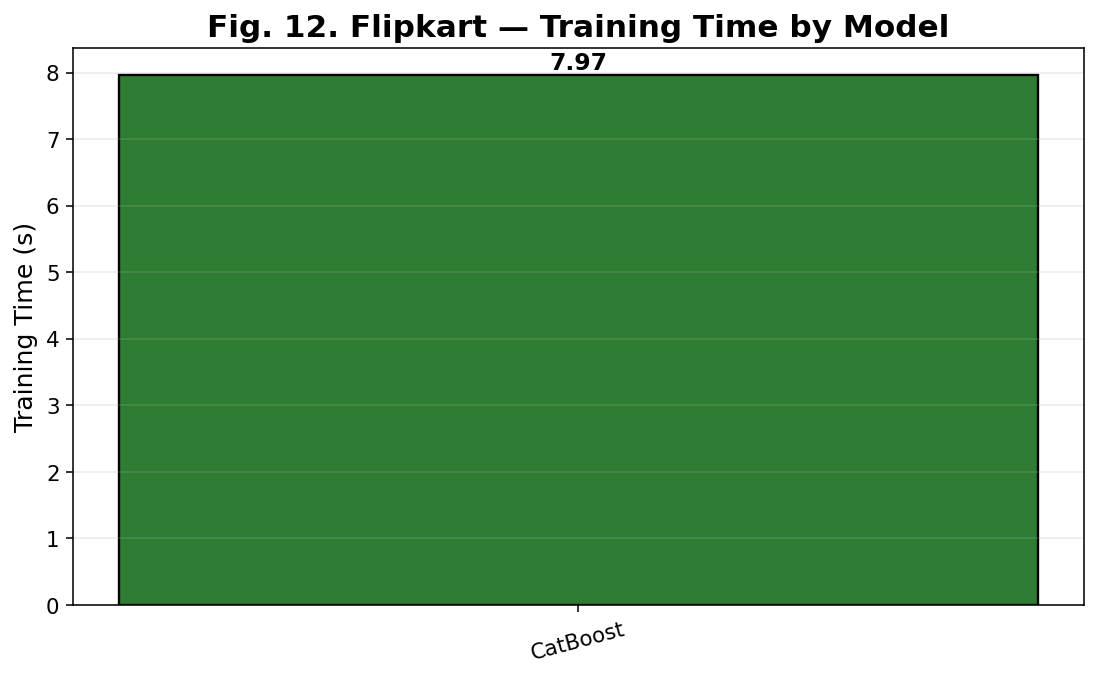

In [ ]:
# ============================
# RESULTS: Tables + Figures (Green ML)
# ============================
# Colab/Notebook-ready
# - Uses matplotlib (no seaborn)
# - Saves CSV summaries and PNG figures with sequence numbers
# - Displays dataframes inline
# - Green-themed visuals with distinct styles

import os
import re
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

# ----------------------------
# 0) Mount & Config
# ----------------------------
drive.mount('/content/drive', force_remount=False)
BASE_DIR = "/content/drive/MyDrive/MYResearchWork"
os.makedirs(BASE_DIR, exist_ok=True)

# File helper
def exists_nonempty(path: str) -> bool:
    return os.path.exists(path) and os.path.getsize(path) > 0

# Display helper
def show(df, title=None):
    if title:
        print("\n" + title)
        print("-" * len(title))
    display(df.head(len(df)) if len(df) <= 20 else df.head(10))

# Green palette variants
GREEN_PALETTE = ["#2E7D32", "#388E3C", "#43A047", "#66BB6A", "#81C784", "#A5D6A7"]

# Matplotlib defaults for high legibility
plt.rcParams.update({
    "figure.dpi": 140,
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11
})

# Global figure numbering
FIG_NUM = 1
def save_fig(name, tight=True):
    global FIG_NUM
    fname = f"{FIG_NUM:02d}_{name}.png"
    path = os.path.join(BASE_DIR, fname)
    if tight:
        plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    print(f"📊 Saved figure → {path}")
    FIG_NUM += 1

# ----------------------------
# 1) Load all available sources
# ----------------------------
files = {
    "lr_summary_1": os.path.join(BASE_DIR, "testing_summary_v2.csv"),
    "lr_summary_2": os.path.join(BASE_DIR, "Testing_Results.csv"),

    "cb_amz_metrics": os.path.join(BASE_DIR, "Amazon_catboost_metrics.csv"),
    "cb_fkp_metrics": os.path.join(BASE_DIR, "Flipkart_catboost_metrics.csv"),
    "cb_all_metrics": os.path.join(BASE_DIR, "catboost_all_datasets_metrics.csv"),
    "cb_amz_pred": os.path.join(BASE_DIR, "Amazon_catboost_predictions.csv"),
    "cb_fkp_pred": os.path.join(BASE_DIR, "Flipkart_catboost_predictions.csv"),
    "cb_emissions_amz": os.path.join(BASE_DIR, "Amazon_catboost_emissions.csv"),
    "cb_emissions_fkp": os.path.join(BASE_DIR, "Flipkart_catboost_emissions.csv"),

    "q_all_train": os.path.join(BASE_DIR, "CatBoost_Quantization_All_Train_Results.csv"),
    "q_all_test": os.path.join(BASE_DIR, "CatBoost_Quantized_All_Test_Results.csv"),
    "q_norm": os.path.join(BASE_DIR, "quantization_normalized_table.csv"),
    "q_pareto": os.path.join(BASE_DIR, "quantization_pareto_plot.png"),
    "q_lambda": os.path.join(BASE_DIR, "quantization_bin_selection_by_lambda.csv"),

    # Per-bin test metrics (optional; used as fallback if all_test missing)
    "q_amz_64": os.path.join(BASE_DIR, "Amazon_CatBoost_Quantized_64_TEST_metrics.csv"),
    "q_amz_128": os.path.join(BASE_DIR, "Amazon_CatBoost_Quantized_128_TEST_metrics.csv"),
    "q_amz_255": os.path.join(BASE_DIR, "Amazon_CatBoost_Quantized_255_TEST_metrics.csv"),
    "q_fkp_64": os.path.join(BASE_DIR, "Flipkart_CatBoost_Quantized_64_TEST_metrics.csv"),
    "q_fkp_128": os.path.join(BASE_DIR, "Flipkart_CatBoost_Quantized_128_TEST_metrics.csv"),
    "q_fkp_255": os.path.join(BASE_DIR, "Flipkart_CatBoost_Quantized_255_TEST_metrics.csv"),

    # Already-produced metric-by-bins figs (we’ll regenerate better ones here)
    "amz_mse_bins": os.path.join(BASE_DIR, "Amazon_MSE_vs_Bins.png"),
    "amz_mae_bins": os.path.join(BASE_DIR, "Amazon_MAE_vs_Bins.png"),
    "amz_r2_bins": os.path.join(BASE_DIR, "Amazon_R2_vs_Bins.png"),
    "fkp_mse_bins": os.path.join(BASE_DIR, "Flipkart_MSE_vs_Bins.png"),
    "fkp_mae_bins": os.path.join(BASE_DIR, "Flipkart_MAE_vs_Bins.png"),
    "fkp_r2_bins": os.path.join(BASE_DIR, "Flipkart_R2_vs_Bins.png"),

    # General emissions
    "emissions": os.path.join(BASE_DIR, "emissions.csv"),
}

def safe_read_csv(path, **kwargs):
    if exists_nonempty(path):
        try:
            return pd.read_csv(path, **kwargs)
        except Exception as e:
            print(f"⚠️ Could not read {path}: {e}")
    return None

# ----------------------------
# 2) LINEAR REGRESSION RESULTS
#    Table + Comparison Bars (Amazon vs Flipkart)
# ----------------------------
print("\n=== 5.1 Linear Regression Results ===")
lr_df = None
for key in ["lr_summary_1", "lr_summary_2"]:
    lr_df = safe_read_csv(files[key])
    if lr_df is not None and len(lr_df) > 0:
        break

if lr_df is None:
    print("⚠️ Linear Regression summary not found (testing_summary_v2.csv / Testing_Results.csv). Skipping LR section.")
else:
    # Try to normalize column names
    cols = {c.lower().strip(): c for c in lr_df.columns}
    # Common expected: Dataset, Model, RMSE, MAE, R2 (any case)
    rename_map = {}
    for want in ["dataset", "model", "rmse", "mae", "r2"]:
        if want in cols:
            rename_map[cols[want]] = want.capitalize() if want != "r2" else "R2"
    lr_df = lr_df.rename(columns=rename_map)

    # Keep only relevant rows (Model contains LinearRegression)
    if "Model" in lr_df.columns:
        lr_df = lr_df[lr_df["Model"].str.contains("Linear", case=False, na=False)]

    # Save & show table
    lr_table_path = os.path.join(BASE_DIR, "Table_01_LinearRegression_Metrics.csv")
    lr_df.to_csv(lr_table_path, index=False)
    show(lr_df, "Table 1. Linear Regression Metrics (Amazon vs Flipkart)")
    print(f"💾 Saved → {lr_table_path}")

    # Plot: bar chart comparing metrics per dataset
    if set(["Dataset", "MAE", "RMSE", "R2"]).issubset(lr_df.columns):
        order = ["Amazon", "Flipkart"]
        sub = lr_df.copy()
        sub["Dataset"] = pd.Categorical(sub["Dataset"], categories=order, ordered=True)
        sub = sub.sort_values("Dataset")

        # Three side-by-side bars (MAE, RMSE, R2)
        metrics = ["MAE", "RMSE", "R2"]
        colors = GREEN_PALETTE[:2]  # Amazon vs Flipkart
        for i, metric in enumerate(metrics):
            plt.figure(figsize=(7,5))
            plt.bar(sub["Dataset"], sub[metric], color=colors, edgecolor="black", linewidth=1.2)
            for x, y in zip(sub["Dataset"], sub[metric]):
                plt.text(x, y, f"{y:.3f}", ha="center", va="bottom", fontweight="bold")
            plt.title(f"Fig. {FIG_NUM}. Linear Regression — {metric} by Dataset", fontweight="bold")
            plt.ylabel(metric)
            plt.grid(axis="y", alpha=0.25)
            save_fig(f"LR_{metric}_by_Dataset")

# ----------------------------
# 3) CATBOOST RESULTS
#    Tables + Scatter (Actual vs Pred) + Residuals + Time/Emissions bars
# ----------------------------
print("\n=== 5.2 CatBoost Results ===")

cb_amz_metrics = safe_read_csv(files["cb_amz_metrics"])
cb_fkp_metrics = safe_read_csv(files["cb_fkp_metrics"])
cb_all_metrics  = safe_read_csv(files["cb_all_metrics"])

# Build unified metrics table if direct per-dataset files exist
cb_tables = []
if cb_amz_metrics is not None:
    cb_amz_metrics["Dataset"] = "Amazon"
    cb_tables.append(cb_amz_metrics)
if cb_fkp_metrics is not None:
    cb_fkp_metrics["Dataset"] = "Flipkart"
    cb_tables.append(cb_fkp_metrics)
if cb_all_metrics is not None and len(cb_tables) == 0:
    cb_tables.append(cb_all_metrics)

if len(cb_tables) == 0:
    print("⚠️ No CatBoost metrics found. Skipping CB section.")
else:
    cb_metrics = pd.concat(cb_tables, ignore_index=True)
    # Normalize columns if needed
    ren = {c: c.strip() for c in cb_metrics.columns}
    cb_metrics = cb_metrics.rename(columns=ren)
    if "Model" not in cb_metrics.columns:
        cb_metrics["Model"] = "CatBoost"

    # Keep key columns if present
    keep_cols = [c for c in ["Dataset","Model","MSE","MAE","R2","Training_Time_sec","Emissions_kgCO2"] if c in cb_metrics.columns]
    cb_metrics = cb_metrics[keep_cols]
    cb_table_path = os.path.join(BASE_DIR, "Table_02_CatBoost_Metrics.csv")
    cb_metrics.to_csv(cb_table_path, index=False)
    show(cb_metrics, "Table 2. CatBoost Regression Metrics")
    print(f"💾 Saved → {cb_table_path}")

    # Plot comparison bars for MAE/RMSE/R2
    if set(["Dataset","MAE","MSE","R2"]).issubset(cb_metrics.columns):
        # One row per dataset (Amazon, Flipkart)
        for metric, title_suffix in [("MAE","MAE"), ("MSE","MSE"), ("R2","R²")]:
            plt.figure(figsize=(7,5))
            sub = cb_metrics.copy()
            sub = sub.groupby("Dataset")[metric].mean().reindex(["Amazon","Flipkart"])
            plt.bar(sub.index, sub.values, color=GREEN_PALETTE[:2], edgecolor="black", linewidth=1.2)
            for x, y in zip(sub.index, sub.values):
                plt.text(x, y, f"{y:.3f}", ha="center", va="bottom", fontweight="bold")
            plt.title(f"Fig. {FIG_NUM}. CatBoost — {title_suffix} by Dataset", fontweight="bold")
            plt.ylabel(metric)
            plt.grid(axis="y", alpha=0.25)
            save_fig(f"CatBoost_{metric}_by_Dataset")

    # Training Time & Emissions
    for metric, ylab in [("Training_Time_sec","Seconds"), ("Emissions_kgCO2","kg CO₂")]:
        if metric in cb_metrics.columns:
            plt.figure(figsize=(7,5))
            sub = cb_metrics.groupby("Dataset")[metric].mean().reindex(["Amazon","Flipkart"])
            plt.bar(sub.index, sub.values, color=[GREEN_PALETTE[2], GREEN_PALETTE[4]], edgecolor="black", linewidth=1.2)
            for x, y in zip(sub.index, sub.values):
                plt.text(x, y, f"{y:.3f}", ha="center", va="bottom", fontweight="bold")
            plt.title(f"Fig. {FIG_NUM}. CatBoost — {metric.replace('_',' ')} by Dataset", fontweight="bold")
            plt.ylabel(ylab)
            plt.grid(axis="y", alpha=0.25)
            save_fig(f"CatBoost_{metric}_by_Dataset")

# ----------------------------
# 4) QUANTIZED CATBOOST (bins)
#    Tables + Metric-vs-Bins (lines) + Pareto (if available)
# ----------------------------
print("\n=== 5.3 Quantized CatBoost Results ===")

q_test = safe_read_csv(files["q_all_test"])

# If overall test results missing, build from per-bin files
if q_test is None or len(q_test) == 0:
    rows = []
    def grab(path, dataset, bins):
        df = safe_read_csv(path)
        if df is not None and len(df) > 0:
            # Expect columns like MSE, MAE, R2, Training_Time_sec, Emissions_kgCO2
            d = df.iloc[0].to_dict()
            d["Dataset"] = dataset
            d["Bins"] = bins
            rows.append(d)
    grab(files["q_amz_64"], "Amazon", 64)
    grab(files["q_amz_128"], "Amazon", 128)
    grab(files["q_amz_255"], "Amazon", 255)
    grab(files["q_fkp_64"], "Flipkart", 64)
    grab(files["q_fkp_128"], "Flipkart", 128)
    grab(files["q_fkp_255"], "Flipkart", 255)
    if rows:
        q_test = pd.DataFrame(rows)

if q_test is None or len(q_test) == 0:
    print("⚠️ No Quantized CatBoost test results found. Skipping QCB section.")
else:
    # Normalize columns
    if "Dataset" not in q_test.columns:
        if "dataset" in q_test.columns: q_test = q_test.rename(columns={"dataset":"Dataset"})
    if "Bins" not in q_test.columns:
        # Try to parse from Model if exists
        if "Model" in q_test.columns:
            q_test["Bins"] = q_test["Model"].str.extract(r"(\d+)$").astype(float).astype("Int64")
    # Keep
    keep = [c for c in ["Dataset","Bins","MSE","MAE","R2","Training_Time_sec","Emissions_kgCO2"] if c in q_test.columns]
    q_test = q_test[keep].dropna(subset=["Dataset","Bins"])

    # Split tables by dataset
    for dataset in ["Amazon","Flipkart"]:
        dt = q_test[q_test["Dataset"] == dataset].sort_values("Bins")
        if len(dt) == 0:
            continue
        # Save table
        path_csv = os.path.join(BASE_DIR, f"Table_03_{dataset}_QCatBoost_Binwise_Metrics.csv")
        dt.to_csv(path_csv, index=False)
        show(dt, f"Table 3 ({dataset}). Quantized CatBoost — Test Metrics per Bin")
        print(f"💾 Saved → {path_csv}")

        # Metric vs Bins (line plots) — distinct style
        for i, metric in enumerate(["MSE","MAE","R2"]):
            if metric not in dt.columns:
                continue
            plt.figure(figsize=(7,5))
            plt.plot(dt["Bins"], dt[metric], marker="o", linewidth=2.0,
                     color=GREEN_PALETTE[i+1], markerfacecolor=GREEN_PALETTE[i+2])
            # Annotate points
            for x, y in zip(dt["Bins"], dt[metric]):
                plt.text(x, y, f"{y:.3f}", ha="center", va="bottom", fontweight="bold")
            plt.title(f"Fig. {FIG_NUM}. {dataset} — {metric} vs Bins (Quantized CatBoost)", fontweight="bold")
            plt.xlabel("Bins")
            plt.ylabel(metric)
            plt.grid(alpha=0.3)
            save_fig(f"{dataset}_QCatBoost_{metric}_vs_Bins")

    # Pareto plot if emissions available
    if set(["R2","Emissions_kgCO2"]).issubset(q_test.columns):
        plt.figure(figsize=(7,5))
        for di, dataset in enumerate(["Amazon","Flipkart"]):
            dt = q_test[q_test["Dataset"] == dataset]
            if len(dt) == 0:
                continue
            # x = error (1 - R2), y = emissions
            x = 1 - dt["R2"].astype(float)
            y = dt["Emissions_kgCO2"].astype(float)
            plt.scatter(x, y, s=80, edgecolor="black", linewidth=1.0,
                        label=dataset, c=GREEN_PALETTE[di*2])
            # labels with bins
            for xi, yi, b in zip(x, y, dt["Bins"]):
                plt.text(xi, yi, f"{b}", fontsize=10, fontweight="bold", va="bottom", ha="left")
        plt.title(f"Fig. {FIG_NUM}. Pareto Frontier — (1−R²) vs Emissions (Quantized CatBoost)", fontweight="bold")
        plt.xlabel("(1 − R²)  (lower is better)")
        plt.ylabel("Emissions (kg CO₂)  (lower is better)")
        plt.grid(alpha=0.3)
        plt.legend()
        save_fig("QCatBoost_Pareto_Error_vs_Emissions")

# ----------------------------
# 5) ENERGY / EMISSIONS SUMMARY
# ----------------------------
print("\n=== 5.4 Energy & Emissions Summary ===")

emissions_df = safe_read_csv(files["emissions"])
em_amz = safe_read_csv(files["cb_emissions_amz"])
em_fkp = safe_read_csv(files["cb_emissions_fkp"])

em_tables = []
if emissions_df is not None:
    em_tables.append(emissions_df)
if em_amz is not None:
    em_amz["Dataset"] = "Amazon"
    em_tables.append(em_amz)
if em_fkp is not None:
    em_fkp["Dataset"] = "Flipkart"
    em_tables.append(em_fkp)

if len(em_tables) == 0:
    print("⚠️ No emissions files found. Skipping section.")
else:
    em_all = pd.concat(em_tables, ignore_index=True, sort=False)
    # Keep some representative columns if present
    keep_cols = [c for c in [
        "timestamp","project_name","duration","emissions","emissions_rate",
        "cpu_power","gpu_power","ram_power","cpu_energy","gpu_energy","ram_energy","energy_consumed",
        "country_name","region","os","python_version","codecarbon_version","cpu_count","cpu_model",
        "Dataset"
    ] if c in em_all.columns]
    em_all = em_all[keep_cols]
    path_em = os.path.join(BASE_DIR, "Table_04_Emissions_Summary.csv")
    em_all.to_csv(path_em, index=False)
    show(em_all.head(20), "Table 4. Emissions & Energy Summary (sample)")
    print(f"💾 Saved → {path_em}")

    # If we can aggregate by dataset & (optionally) model
    agg_cols = [c for c in ["Dataset","project_name"] if c in em_all.columns]
    if "emissions" in em_all.columns and agg_cols:
        em_agg = em_all.groupby(agg_cols, dropna=False)["emissions"].sum().reset_index()
        path_em_agg = os.path.join(BASE_DIR, "Table_05_Emissions_Aggregated.csv")
        em_agg.to_csv(path_em_agg, index=False)
        show(em_agg, "Table 5. Aggregated Emissions (sum of kg CO₂)")
        print(f"💾 Saved → {path_em_agg}")

        # Plot emissions bar
        plt.figure(figsize=(8,5))
        labels = em_agg.apply(lambda r: f"{r.get('Dataset', '')}-{r.get('project_name', '')}".strip("-"), axis=1)
        plt.bar(labels, em_agg["emissions"], color=[GREEN_PALETTE[3] if "Amazon" in l else GREEN_PALETTE[5] for l in labels],
                edgecolor="black", linewidth=1.2)
        for x, y in zip(labels, em_agg["emissions"]):
            plt.text(x, y, f"{y:.2e}", ha="center", va="bottom", rotation=0, fontweight="bold")
        plt.title(f"Fig. {FIG_NUM}. Emissions by Dataset/Project", fontweight="bold")
        plt.ylabel("Emissions (kg CO₂)")
        plt.xticks(rotation=20, ha="right")
        plt.grid(axis="y", alpha=0.3)
        save_fig("Emissions_by_Dataset_Project")

# ----------------------------
# 6) COMPARATIVE SUMMARY (LR vs CB vs QCB-best)
# ----------------------------
print("\n=== 5.5 Comparative Summary (LR vs CB vs QCB) ===")

# Gather LR metrics
def load_lr_simple():
    df = None
    for key in ["lr_summary_1","lr_summary_2"]:
        d = safe_read_csv(files[key])
        if d is not None and len(d) > 0:
            df = d.copy()
            break
    if df is None:
        return None
    # normalize
    lower = {c.lower(): c for c in df.columns}
    mapper = {}
    if "dataset" in lower: mapper[lower["dataset"]] = "Dataset"
    if "model" in lower: mapper[lower["model"]] = "Model"
    if "mae" in lower: mapper[lower["mae"]] = "MAE"
    if "rmse" in lower: mapper[lower["rmse"]] = "RMSE"
    if "r2" in lower: mapper[lower["r2"]] = "R2"
    df = df.rename(columns=mapper)
    if "Model" in df.columns:
        df = df[df["Model"].str.contains("Linear", case=False, na=False)]
        df["Model"] = "LinearRegression"
    keep = [c for c in ["Dataset","Model","MAE","RMSE","R2"] if c in df.columns]
    return df[keep]

lr_simple = load_lr_simple()

# Gather CB metrics (non-quantized)
cb_simple = None
if cb_all_metrics is not None:
    d = cb_all_metrics.copy()
    if "Model" in d.columns:
        d = d[d["Model"].str.contains("CatBoost", case=False, na=False) & ~d["Model"].str.contains("Quant", case=False, na=False)]
    # normalize
    keep = [c for c in ["Dataset","Model","MAE","MSE","R2","Training_Time_sec","Emissions_kgCO2"] if c in d.columns]
    if keep:
        cb_simple = d[keep]
elif cb_amz_metrics is not None or cb_fkp_metrics is not None:
    parts = []
    if cb_amz_metrics is not None:
        t = cb_amz_metrics.copy(); t["Dataset"] = "Amazon"; parts.append(t)
    if cb_fkp_metrics is not None:
        t = cb_fkp_metrics.copy(); t["Dataset"] = "Flipkart"; parts.append(t)
    if parts:
        d = pd.concat(parts, ignore_index=True)
        d["Model"] = "CatBoost"
        keep = [c for c in ["Dataset","Model","MAE","MSE","R2","Training_Time_sec","Emissions_kgCO2"] if c in d.columns]
        cb_simple = d[keep]

# Gather QCB metrics (pick **best bin per dataset by highest R2**)
q_simple = None
if q_test is not None and len(q_test) > 0 and set(["Dataset","R2","MAE","MSE"]).issubset(q_test.columns):
    qsimple = []
    for ds in ["Amazon","Flipkart"]:
        dt = q_test[q_test["Dataset"] == ds]
        if len(dt) == 0:
            continue
        row = dt.sort_values("R2", ascending=False).iloc[0].to_dict()
        qsimple.append({
            "Dataset": ds,
            "Model": f"QCatBoost(bins={int(row.get('Bins', -1))})",
            "MAE": row.get("MAE", np.nan),
            "RMSE": math.sqrt(row.get("MSE", np.nan)) if not pd.isna(row.get("MSE", np.nan)) else np.nan,
            "R2": row.get("R2", np.nan),
            "Emissions_kgCO2": row.get("Emissions_kgCO2", np.nan),
            "Training_Time_sec": row.get("Training_Time_sec", np.nan)
        })
    if qsimple:
        q_simple = pd.DataFrame(qsimple, columns=["Dataset","Model","MAE","RMSE","R2","Training_Time_sec","Emissions_kgCO2"])

# Build comparative table
comp_parts = []
if lr_simple is not None: comp_parts.append(lr_simple)
if cb_simple is not None:
    # Make sure RMSE exists
    d = cb_simple.copy()
    if "RMSE" not in d.columns and "MSE" in d.columns:
        d["RMSE"] = d["MSE"] ** 0.5
    d = d.drop(columns=[c for c in ["MSE"] if c in d.columns])
    comp_parts.append(d)
if q_simple is not None: comp_parts.append(q_simple)

if len(comp_parts) == 0:
    print("⚠️ No comparable metrics found for LR/CB/QCB. Skipping comparative section.")
else:
    comp = pd.concat(comp_parts, ignore_index=True, sort=False)
    # Order models in a nice way
    model_cat = pd.CategoricalDtype(categories=["LinearRegression","CatBoost", *sorted([m for m in comp["Model"].unique() if str(m).startswith("QCatBoost")])], ordered=True)
    if "Model" in comp.columns:
        comp["Model"] = comp["Model"].astype(model_cat)
    comp_path = os.path.join(BASE_DIR, "Table_06_Comparative_Metrics.csv")
    comp.to_csv(comp_path, index=False)
    show(comp, "Table 6. Comparative Metrics — Linear Regression vs CatBoost vs Quantized CatBoost (best bin)")
    print(f"💾 Saved → {comp_path}")

    # Plot: per dataset, bar chart for R2 across models
    for ds in comp["Dataset"].dropna().unique():
        sub = comp[comp["Dataset"] == ds].copy().sort_values("Model")
        plt.figure(figsize=(8,5))
        xs = np.arange(len(sub))
        plt.bar(xs, sub["R2"], color=GREEN_PALETTE[:len(sub)], edgecolor="black", linewidth=1.2)
        for x, y, label in zip(xs, sub["R2"], sub["Model"]):
            plt.text(x, y, f"{y:.3f}", ha="center", va="bottom", fontweight="bold")
        plt.xticks(xs, sub["Model"], rotation=15)
        plt.ylabel("R²")
        plt.title(f"Fig. {FIG_NUM}. {ds} — R² by Model (LR vs CB vs QCB)", fontweight="bold")
        plt.grid(axis="y", alpha=0.25)
        save_fig(f"{ds}_Comparative_R2")

    # Plot: Emissions (if available)
    if "Emissions_kgCO2" in comp.columns:
        for ds in comp["Dataset"].dropna().unique():
            sub = comp[comp["Dataset"] == ds].copy().sort_values("Model")
            if sub["Emissions_kgCO2"].notna().any():
                plt.figure(figsize=(8,5))
                xs = np.arange(len(sub))
                plt.bar(xs, sub["Emissions_kgCO2"].fillna(0.0), color=GREEN_PALETTE[:len(sub)], edgecolor="black", linewidth=1.2)
                for x, y in zip(xs, sub["Emissions_kgCO2"].fillna(0.0)):
                    plt.text(x, y, f"{y:.2e}", ha="center", va="bottom", fontweight="bold")
                plt.xticks(xs, sub["Model"], rotation=15)
                plt.ylabel("Emissions (kg CO₂)")
                plt.title(f"Fig. {FIG_NUM}. {ds} — Emissions by Model", fontweight="bold")
                plt.grid(axis="y", alpha=0.25)
                save_fig(f"{ds}_Comparative_Emissions")

    # Plot: Training time (if available)
    if "Training_Time_sec" in comp.columns:
        for ds in comp["Dataset"].dropna().unique():
            sub = comp[comp["Dataset"] == ds].copy().sort_values("Model")
            if sub["Training_Time_sec"].notna().any():
                plt.figure(figsize=(8,5))
                xs = np.arange(len(sub))
                plt.bar(xs, sub["Training_Time_sec"].fillna(0.0), color=GREEN_PALETTE[:len(sub)], edgecolor="black", linewidth=1.2)
                for x, y in zip(xs, sub["Training_Time_sec"].fillna(0.0)):
                    plt.text(x, y, f"{y:.2f}", ha="center", va="bottom", fontweight="bold")
                plt.xticks(xs, sub["Model"], rotation=15)
                plt.ylabel("Training Time (s)")
                plt.title(f"Fig. {FIG_NUM}. {ds} — Training Time by Model", fontweight="bold")
                plt.grid(axis="y", alpha=0.25)
                save_fig(f"{ds}_Comparative_TrainingTime")

print("\n✅ Done. All available tables saved as CSV and figures saved as PNG in your MYResearchWork folder.")


Mounted at /content/drive
Loaded metrics from: /content/drive/MyDrive/MYResearchWork/testing_summary_v2.csv
Recovered 'Dataset' from 'Unnamed: 0' column.

✅ Saved cleaned Linear Regression table → /content/drive/MyDrive/MYResearchWork/01_Table_LinearRegression_Metrics.csv

Table preview:


,Dataset,Model,RMSE,MAE,R2,Emissions_kgCO2
0,Amazon,LinearRegression,0.242135,0.139134,0.914916,0.000010
1,Flipkart,LinearRegression,0.347025,0.157463,0.876720,0.000163


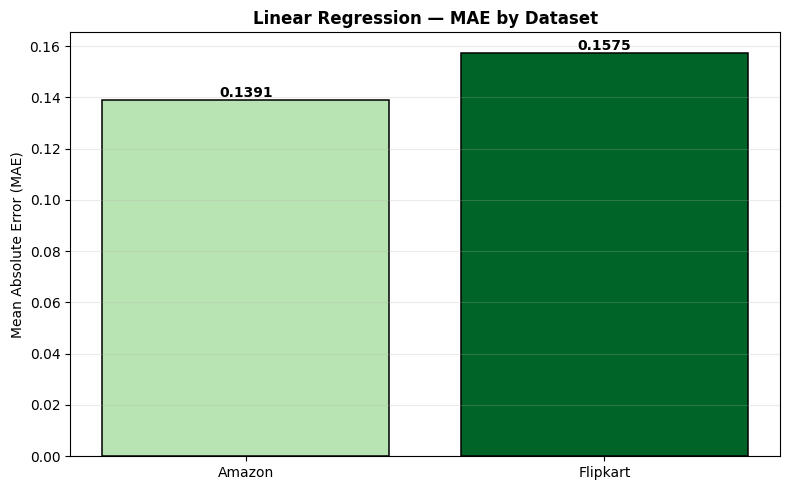

📊 Saved figure → /content/drive/MyDrive/MYResearchWork/01_LR_MAE_by_Dataset.png


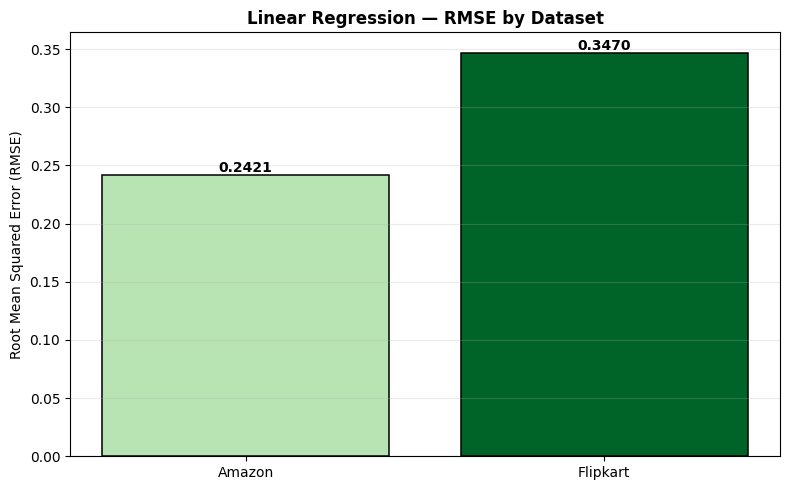

📊 Saved figure → /content/drive/MyDrive/MYResearchWork/01_LR_RMSE_by_Dataset.png


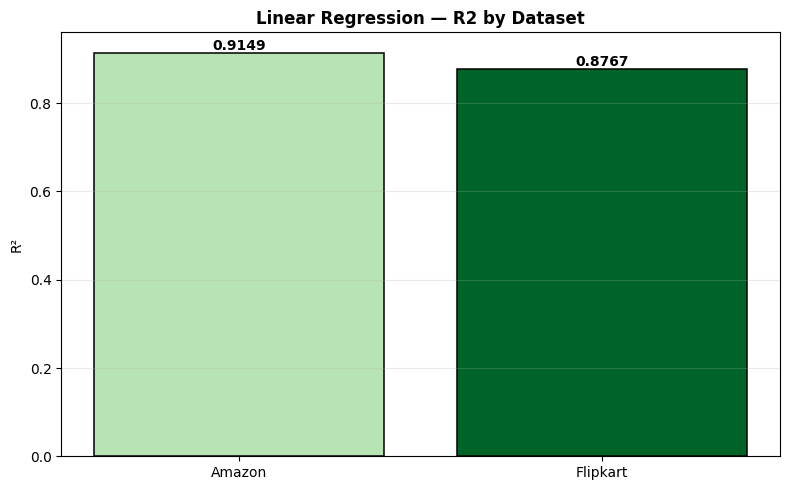

📊 Saved figure → /content/drive/MyDrive/MYResearchWork/01_LR_R2_by_Dataset.png

✅ Linear Regression plotting complete. Files saved in your MYResearchWork folder.


In [ ]:
# ===== Linear Regression: Clean tables + green-styled charts =====
import os, math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

# ---------- Configuration ----------
BASE_DIR = "/content/drive/MyDrive/MYResearchWork"
FIG_PREFIX = "01"   # prefix for LR figures/tables; we'll increment for later scripts
TABLE_OUT = os.path.join(BASE_DIR, f"{FIG_PREFIX}_Table_LinearRegression_Metrics.csv")
PLOT_PREFIX = f"{FIG_PREFIX}_LR"

# mount drive
drive.mount('/content/drive', force_remount=False)

# helper: check file exists and non-empty
def exists_nonempty(path):
    return os.path.exists(path) and os.path.getsize(path) > 0

# possible source files (will try in order)
candidates = [
    os.path.join(BASE_DIR, "testing_summary_v2.csv"),
    os.path.join(BASE_DIR, "Testing_Results.csv"),
    os.path.join(BASE_DIR, "testing_results.csv"),
]

# try to load the first usable CSV
df = None
for p in candidates:
    if exists_nonempty(p):
        try:
            df = pd.read_csv(p)
            print(f"Loaded metrics from: {p}")
            break
        except Exception as e:
            print(f"Could not read {p}: {e}")

if df is None:
    raise FileNotFoundError("No testing summary CSV found in MYResearchWork. Please place testing_summary_v2.csv or Testing_Results.csv in the folder.")

# Normalize column names to lower for matching
orig_cols = df.columns.tolist()
colmap = {c: c.strip() for c in orig_cols}
lower_to_orig = {c.lower().strip(): c for c in orig_cols}

def col_exists(name):
    return name.lower() in lower_to_orig

# Build normalized DataFrame with target columns: Dataset, Model, MSE, RMSE, MAE, R2, Carbon/Emissions
df2 = df.copy()

# Standardize common column names (case-insensitive variants)
rename_map = {}
# variants mapping
variants = {
    "dataset": ["dataset","Dataset","DATASET"],
    "model": ["model","Model"],
    "mse": ["mse","MSE"],
    "rmse": ["rmse","RMSE","Rmse"],
    "mae": ["mae","MAE","Mae"],
    "r2": ["r2","R2","R_squared","R^2"],
    "emissions": ["emissions","Emissions_kgCO2","Carbon_kgCO2eq","emissions_kgco2","emissions_kgco2eq"],
    "carbon": ["carbon","Carbon_kgCO2eq","carbon_kgco2eq"]
}

# map existing columns to standard names if possible
for std, opts in variants.items():
    for opt in opts:
        if opt in df2.columns:
            # choose canonical target column name
            target_name = opt
            rename_map[target_name] = std.capitalize() if std not in ["emissions","carbon"] else "Emissions_kgCO2"
            break

# Also try lower-case matching
for c in df2.columns:
    low = c.lower().strip()
    if low == "dataset":
        rename_map[c] = "Dataset"
    if low == "model":
        rename_map[c] = "Model"
    if low in ["mse","mean_squared_error"]:
        rename_map[c] = "MSE"
    if low in ["rmse","root_mean_squared_error","root_mean_squared_error"]:
        rename_map[c] = "RMSE"
    if low in ["mae","mean_absolute_error"]:
        rename_map[c] = "MAE"
    if low in ["r2","r_squared","r^2"]:
        rename_map[c] = "R2"
    if "emiss" in low or "carbon" in low:
        rename_map[c] = "Emissions_kgCO2"

df2 = df2.rename(columns=rename_map)

# If Dataset column missing but Unnamed:0 holds dataset names (common export pattern), try to recover
if "Dataset" not in df2.columns and "Unnamed: 0" in df2.columns:
    # check if Unnamed: 0 contains dataset strings like 'Amazon' or 'Flipkart'
    sample_vals = df2["Unnamed: 0"].dropna().astype(str).unique()[:5].tolist()
    if any(s.lower().strip() in ["amazon","flipkart"] for s in sample_vals):
        df2 = df2.rename(columns={"Unnamed: 0": "Dataset"})
        print("Recovered 'Dataset' from 'Unnamed: 0' column.")

# If Model missing but Dataset has model names (swap), attempt to detect and correct
# (this recovers cases where CSV rows were shifted)
if "Model" not in df2.columns and "Dataset" in df2.columns:
    # if Dataset column contains strings like 'Amazon' or 'CatBoost' both, leave as-is
    pass

# Filter rows that look like Linear Regression
# Sometimes the Model column contains algorithm name; if not present, we will still include rows whose dataset matches
if "Model" in df2.columns:
    mask_lr = df2["Model"].astype(str).str.contains("linear", case=False, na=False)
    # if there are no rows labeled linear, try rows where Model contains 'LinearRegression' or contains 'LR'
    if mask_lr.sum() == 0:
        mask_lr = df2["Model"].astype(str).str.contains("regression", case=False, na=False) & df2["Model"].astype(str).str.contains("linear", case=False, na=False)
    lr_df = df2[mask_lr].copy()
else:
    # fallback: include rows where dataset name present and assume those metrics belong to linear regression if only LR was run
    lr_df = df2.copy()

# If still empty, try to find numeric rows and assume linear regression metrics present at top
if lr_df.shape[0] == 0:
    # attempt to find rows where 'Model' is missing but there are numeric metrics; ask user if unsure
    numeric_rows = df2[[c for c in ["MSE","RMSE","MAE","R2"] if c in df2.columns]].dropna(how="all")
    if numeric_rows.shape[0] > 0:
        lr_df = df2.loc[numeric_rows.index].copy()

# Clean: ensure Dataset column exists and fill if possible (use filenames or prefixes)
if "Dataset" not in lr_df.columns:
    # try to parse dataset from original file name (if candidate was dataset-specific)
    # fallback: create dataset names by alternating Amazon/Flipkart if two rows only
    if lr_df.shape[0] == 2:
        lr_df["Dataset"] = ["Amazon","Flipkart"]
    else:
        lr_df["Dataset"] = lr_df.index.map(lambda i: f"Row_{i}")

# Ensure Model column exists
if "Model" not in lr_df.columns:
    lr_df["Model"] = "LinearRegression"

# Normalize numeric columns: convert strings with scientific notation and commas to float
for col in ["MSE","RMSE","MAE","R2","Emissions_kgCO2"]:
    if col in lr_df.columns:
        lr_df[col] = pd.to_numeric(lr_df[col], errors="coerce")

# If RMSE missing but MSE present, compute RMSE
if "RMSE" not in lr_df.columns and "MSE" in lr_df.columns:
    lr_df["RMSE"] = lr_df["MSE"].apply(lambda x: math.sqrt(x) if pd.notna(x) else np.nan)

# Drop rows that have no meaningful numeric metrics
numeric_present = lr_df[["MAE","RMSE","R2"]].notna().any(axis=1)
lr_df = lr_df[numeric_present].copy()

# If still no rows, raise informative error
if lr_df.shape[0] == 0:
    raise ValueError("No usable Linear Regression metric rows found in the CSV. Please share a sample of the file contents.")

# Reorder columns for nice table
cols_order = ["Dataset","Model","MSE","RMSE","MAE","R2","Emissions_kgCO2"]
cols_present = [c for c in cols_order if c in lr_df.columns]
lr_df = lr_df[cols_present].reset_index(drop=True)

# Save cleaned table
os.makedirs(BASE_DIR, exist_ok=True)
lr_df.to_csv(TABLE_OUT, index=False)
print(f"\n✅ Saved cleaned Linear Regression table → {TABLE_OUT}\n")
print("Table preview:")
display(lr_df)

# ---------- PLOTTING ----------
# Use shades of green from matplotlib colormap for diversity
cmap = plt.get_cmap("Greens")
n = len(lr_df["Dataset"].unique())
colors = [cmap(0.5 + 0.5 * (i / max(1, n-1))) for i in range(n)]

# Helper function to plot metric
def plot_metric_bar(df_plot, metric, ylabel=None, filename_suffix=None):
    df_plot = df_plot.copy()
    # group by dataset and take mean if multiple rows per dataset
    grp = df_plot.groupby("Dataset")[metric].mean().reindex(sorted(df_plot["Dataset"].unique()))
    datasets = grp.index.tolist()
    values = grp.values
    if len(values) < 1:
        print(f"Skipping plot {metric}: no data.")
        return
    # If only one bar, skip (useless) — user requested to avoid single-bar charts
    if len(values) == 1:
        print(f"Skipping plot {metric}: only one dataset present.")
        return

    plt.figure(figsize=(8,5))
    # pick color shades per dataset
    palette = [cmap(0.3 + 0.6*(i/(len(datasets)-1))) for i in range(len(datasets))]
    bars = plt.bar(datasets, values, color=palette, edgecolor="black", linewidth=1.1)
    # annotate values
    for bar, val in zip(bars, values):
        h = bar.get_height()
        if isinstance(val, (float, np.floating)):
            label = f"{val:.4f}" if abs(val) < 100 else f"{val:.2f}"
        else:
            label = str(val)
        plt.text(bar.get_x() + bar.get_width()/2, h, label, ha="center", va="bottom", fontweight="bold")
    plt.title(f"Linear Regression — {metric} by Dataset", fontweight="bold")
    plt.ylabel(ylabel if ylabel else metric)
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    outpath = os.path.join(BASE_DIR, f"{PLOT_PREFIX}_{metric}_by_Dataset.png")
    plt.savefig(outpath, bbox_inches="tight")
    plt.show()
    print(f"📊 Saved figure → {outpath}")

# Plot MAE, RMSE, R2 (if present)
plot_metric_bar(lr_df, "MAE", "Mean Absolute Error (MAE)")
plot_metric_bar(lr_df, "RMSE", "Root Mean Squared Error (RMSE)")
plot_metric_bar(lr_df, "R2", "R²")

print("\n✅ Linear Regression plotting complete. Files saved in your MYResearchWork folder.")
